# Analisis Sentimen Hoax Deepfake pada Komentar TikTok Menggunakan LSTM

Dokumen ini menyajikan analisis sentimen terhadap komentar TikTok yang berkaitan dengan isu hoax deepfake. Uraian disusun dalam satu alur metodologis yang mencakup penyiapan data, pra-pemrosesan teks, pelabelan otomatis, pembentukan representasi vektor, pemodelan Long Short-Term Memory (LSTM), evaluasi kinerja, dan pengujian ablasi, sehingga hubungan antarbagian dapat dipahami secara runtut dan koheren.

In [51]:
# Cell 0 - Setup lingkungan kerja
# Keseragaman lingkungan komputasi merupakan prasyarat bagi pelaksanaan analisis yang dapat
# direplikasi. Oleh karena itu, konfigurasi pustaka dan direktori kerja ditetapkan sejak awal
# agar seluruh proses, mulai dari pengolahan data hingga penyimpanan artefak model, berlangsung
# pada struktur komputasi yang konsisten.

import sys
import subprocess
import pkgutil

required_packages = {
    'pandas': 'pandas',
    'numpy': 'numpy',
    'matplotlib': 'matplotlib',
    'seaborn': 'seaborn',
    'openpyxl': 'openpyxl',
    'nltk': 'nltk',
    'gensim': 'gensim',
    'Sastrawi': 'Sastrawi',
    'textblob': 'textblob',
    'deep-translator': 'deep_translator',
    'wordcloud': 'wordcloud',
    'imbalanced-learn': 'imblearn',
    'scikit-learn': 'sklearn',
    'tensorflow': 'tensorflow',
    'ipywidgets': 'ipywidgets',
    'tqdm': 'tqdm',
    'pydot': 'pydot'
}

for package_name, import_name in required_packages.items():
    if pkgutil.find_loader(import_name) is None:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', package_name])

import nltk
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

print('Setup selesai. Seluruh pustaka utama telah disiapkan.')


Setup selesai. Seluruh pustaka utama telah disiapkan.


In [52]:
pip install --upgrade pip

Note: you may need to restart the kernel to use updated packages.


In [53]:
import matplotlib
import seaborn as sns
print(matplotlib.__version__)
print(sns.__version__)

3.9.2
0.13.2


In [54]:
# Cell 1 - Import library yang dibutuhkan
# Pustaka yang relevan dihimpun dalam satu bagian untuk menegaskan ruang lingkup komputasi yang
# digunakan. Pengelompokan ini memudahkan penelusuran metodologis karena seluruh dependensi utama
# bagi pemrosesan teks, representasi vektor, pembelajaran model, evaluasi, dan visualisasi
# terdokumentasi secara eksplisit.

import json
import os
import pickle
import random
import re
import textwrap
import unicodedata
import warnings
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from tqdm.auto import tqdm
from wordcloud import WordCloud

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

from deep_translator import GoogleTranslator
from textblob import TextBlob

from gensim.models import Word2Vec

from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
    roc_auc_score,
    roc_curve,
    auc
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
from sklearn.metrics.pairwise import cosine_similarity

from imblearn.over_sampling import RandomOverSampler

import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.layers import LSTM, Dense, Dropout, Embedding, SpatialDropout1D
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.utils import to_categorical, plot_model

import ipywidgets as widgets
from IPython.display import Image, Markdown, clear_output, display

warnings.filterwarnings('ignore')
tqdm.pandas()

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

BASE_DIR = Path.cwd()
FIG_DIR = BASE_DIR / 'figures'
MODEL_DIR = BASE_DIR / 'artifacts'
FIG_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style='whitegrid', context='talk')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['savefig.dpi'] = 300

def save_figure(filename, dpi=300):
    figure_path = FIG_DIR / filename
    plt.savefig(figure_path, dpi=dpi, bbox_inches='tight')
    return figure_path

print(f'Direktori kerja aktif: {BASE_DIR}')
print(f'Direktori gambar: {FIG_DIR}')
print(f'Direktori artefak model: {MODEL_DIR}')


Direktori kerja aktif: d:\sentimen-LTSM
Direktori gambar: d:\sentimen-LTSM\figures
Direktori artefak model: d:\sentimen-LTSM\artifacts


In [57]:
# Cell 2 - Import dataset
# Analisis dimulai dari pemuatan data primer penelitian yang tersimpan pada berkas lokal. Mekanisme
# pembacaan dirancang cukup fleksibel terhadap format penyimpanan yang lazim digunakan sehingga
# korpus dapat diakses secara konsisten tanpa mengubah rancangan utama penelitian.

candidate_dataset_files = [
    *sorted(BASE_DIR.glob('komentar_tiktok.*')),
    *sorted(BASE_DIR.glob('*komentar*tiktok*')),
    *sorted(BASE_DIR.glob('*.xlsx')),
    *sorted(BASE_DIR.glob('*.csv'))
]

if not candidate_dataset_files:
    raise FileNotFoundError('Dataset tidak ditemukan pada direktori kerja.')

dataset_path = candidate_dataset_files[0]
if dataset_path.suffix.lower() in ['.xlsx', '.xls']:
    df_raw = pd.read_excel(dataset_path)
elif dataset_path.suffix.lower() == '.csv':
    df_raw = pd.read_csv(dataset_path)
else:
    raise ValueError(f'Format dataset belum didukung: {dataset_path.suffix}')

print(f'Dataset aktif: {dataset_path.name}')
print(f'Ukuran data awal: {df_raw.shape[0]} baris x {df_raw.shape[1]} kolom')
display(df_raw.head())


Dataset aktif: komentar_tiktok.csv
Ukuran data awal: 1743 baris x 6 kolom


,Username,comment,sentimen,label_int,skor,alasan
0,latif,bisa aja ngeles yaa 😂,negative,0,-1.25,neg=['berkilah'] pos=[] emoji=-0.5
1,kangyana295,tolong di usut yang mengedit vidio.. tangkap aja.,neutral,1,0.00,(tidak ada sinyal sentimen)
2,',liat itu real\nliat aja mulut nya,neutral,1,0.00,(tidak ada sinyal sentimen)
3,WT,video asli bru muncul setelah beliau mengundur...,neutral,1,0.00,(tidak ada sinyal sentimen)
4,𝙆𝙞𝙣𝙜 𝙢𝙖𝙘👑,hoak nya di mana AI maksud nya gua yg suka bik...,neutral,1,0.00,(tidak ada sinyal sentimen)


In [58]:
# Cell 3 - Ambil kolom yang dibutuhkan
# Setelah data dimuat, perhatian diarahkan pada atribut yang benar-benar relevan bagi analisis
# sentimen. Seleksi kolom, standardisasi nama atribut, penghapusan nilai kosong, dan eliminasi
# duplikasi dilakukan untuk memperoleh korpus yang lebih bersih dan lebih representatif terhadap
# opini publik yang menjadi objek penelitian.

comment_candidates = ['comment', 'komentar', 'ulasan', 'text', 'teks']
username_candidates = ['username', 'user', 'nama', 'akun']

normalized_columns = {col.lower().strip(): col for col in df_raw.columns}

comment_col = None
for candidate in comment_candidates:
    if candidate in normalized_columns:
        comment_col = normalized_columns[candidate]
        break

if comment_col is None:
    raise KeyError('Kolom komentar tidak ditemukan pada dataset.')

username_col = None
for candidate in username_candidates:
    if candidate in normalized_columns:
        username_col = normalized_columns[candidate]
        break

selected_columns = [comment_col] + ([username_col] if username_col else [])
df = df_raw[selected_columns].copy()
df = df.rename(columns={comment_col: 'text_raw'})
if username_col:
    df = df.rename(columns={username_col: 'username'})
else:
    df['username'] = 'unknown'

df['text_raw'] = df['text_raw'].astype(str).str.strip()
df = df.replace({'text_raw': {'': np.nan, 'nan': np.nan, 'None': np.nan}})
df = df.dropna(subset=['text_raw']).drop_duplicates(subset=['text_raw']).reset_index(drop=True)

print(f'Ukuran data setelah seleksi kolom: {df.shape[0]} baris')
display(df.head())


Ukuran data setelah seleksi kolom: 1743 baris


,text_raw,username
0,bisa aja ngeles yaa 😂,latif
1,tolong di usut yang mengedit vidio.. tangkap aja.,kangyana295
2,liat itu real\nliat aja mulut nya,'
3,video asli bru muncul setelah beliau mengundur...,WT
4,hoak nya di mana AI maksud nya gua yg suka bik...,𝙆𝙞𝙣𝙜 𝙢𝙖𝙘👑


In [59]:
# Cell 3.1 - Muat kamus combined_slang_words
# Karakter informal komentar media sosial menuntut adanya kamus normalisasi yang memetakan bentuk
# tidak baku ke bentuk baku. Berkas kamus tersebut dibaca dan diubah ke dalam struktur yang dapat
# diterapkan secara sistematis agar variasi leksikal yang bersifat slang tidak menurunkan
# konsistensi korpus.

candidate_slang_files = []
for pattern in ['*combined*slang*', '*slang*', '*normalisasi*']:
    candidate_slang_files.extend(sorted(BASE_DIR.glob(pattern)))

candidate_slang_files = [path for path in candidate_slang_files if path.is_file()]
if not candidate_slang_files:
    raise FileNotFoundError('Berkas combined_slang_words tidak ditemukan pada direktori kerja.')

slang_path = candidate_slang_files[0]

def parse_text_mapping(lines):
    mapping = {}
    for line in lines:
        cleaned_line = line.strip()
        if not cleaned_line or cleaned_line.startswith('#'):
            continue
        if '\t' in cleaned_line:
            parts = cleaned_line.split('\t')
        elif ',' in cleaned_line:
            parts = cleaned_line.split(',')
        elif ';' in cleaned_line:
            parts = cleaned_line.split(';')
        elif ':' in cleaned_line:
            parts = cleaned_line.split(':')
        else:
            continue
        if len(parts) >= 2:
            slang = parts[0].strip().lower()
            formal = parts[1].strip().lower()
            if slang and formal:
                mapping[slang] = formal
    return mapping

def load_slang_dictionary(path):
    suffix = path.suffix.lower()
    if suffix in ['.xlsx', '.xls']:
        slang_df = pd.read_excel(path)
    elif suffix in ['.csv', '.tsv']:
        sep = '\t' if suffix == '.tsv' else ','
        slang_df = pd.read_csv(path, sep=sep)
    elif suffix == '.json':
        with open(path, 'r', encoding='utf-8') as f:
            payload = json.load(f)
        if isinstance(payload, dict):
            return {str(k).lower(): str(v).lower() for k, v in payload.items()}
        if isinstance(payload, list):
            payload_df = pd.DataFrame(payload)
            slang_df = payload_df.copy()
        else:
            raise ValueError('Format JSON untuk kamus slang tidak dikenali.')
    elif suffix in ['.txt', '.dic']:
        # Berkas combined_slang_words.txt sebenarnya berformat JSON
        # {"slang": "baku", ...}; coba parse JSON dulu agar normalisasi aktif.
        with open(path, 'r', encoding='utf-8') as f:
            content = f.read()
        try:
            payload = json.loads(content)
            if isinstance(payload, dict):
                return {str(k).lower().strip(): str(v).lower().strip() for k, v in payload.items()}
        except json.JSONDecodeError:
            pass
        return parse_text_mapping(content.splitlines())
    else:
        raise ValueError(f'Format berkas slang belum didukung: {suffix}')

    slang_df.columns = [str(col).strip().lower() for col in slang_df.columns]
    possible_source = ['slang', 'kata_tidak_baku', 'informal', 'before', 'asal', 'source']
    possible_target = ['formal', 'kata_baku', 'normalized', 'after', 'tujuan', 'target']

    source_col = next((col for col in possible_source if col in slang_df.columns), slang_df.columns[0])
    target_col = next((col for col in possible_target if col in slang_df.columns), slang_df.columns[1])

    slang_df = slang_df[[source_col, target_col]].dropna().copy()
    slang_df[source_col] = slang_df[source_col].astype(str).str.strip().str.lower()
    slang_df[target_col] = slang_df[target_col].astype(str).str.strip().str.lower()
    slang_df = slang_df[(slang_df[source_col] != '') & (slang_df[target_col] != '')]

    return dict(zip(slang_df[source_col], slang_df[target_col]))

slang_dict = load_slang_dictionary(slang_path)
sample_slang = pd.DataFrame(list(slang_dict.items())[:10], columns=['bentuk_tidak_baku', 'bentuk_baku'])

print(f'Kamus normalisasi aktif: {slang_path.name}')
print(f'Jumlah entri kamus: {len(slang_dict):,}')
display(sample_slang)


Kamus normalisasi aktif: combined_slang_words.txt
Jumlah entri kamus: 1,018


,bentuk_tidak_baku,bentuk_baku
0,@,di
1,abis,habis
2,ad,ada
3,adlh,adalah
4,afaik,as far as i know
5,ahaha,haha
6,aj,saja
7,ajep-ajep,dunia gemerlap
8,ak,saya
9,akika,aku


In [60]:
# Cell 3.2 - Definisikan resource preprocessing
# Atas dasar korpus yang telah dipilih, sumber daya linguistik yang menopang pra-pemrosesan
# ditetapkan terlebih dahulu. Stopword, kata negasi, stemmer, dan lemmatizer didefinisikan secara
# eksplisit karena masing-masing unsur tersebut memengaruhi cara makna sentimen dipertahankan atau
# direduksi sepanjang proses transformasi teks.

indonesian_stopwords = set(stopwords.words('indonesian'))
additional_stopwords = {
    'nih', 'sih', 'deh', 'dong', 'ya', 'yaa', 'aja', 'lah', 'kok', 'kan', 'nya'
}
negation_words = {'tidak', 'tak', 'bukan', 'jangan', 'belum', 'ga', 'gak', 'nggak', 'enggak'}
stopword_set = (indonesian_stopwords | additional_stopwords) - negation_words

stemmer = StemmerFactory().create_stemmer()
lemmatizer = WordNetLemmatizer()

print(f'Jumlah stopword efektif: {len(stopword_set):,}')
print(f'Jumlah kata negasi yang dipertahankan: {len(negation_words)}')


Jumlah stopword efektif: 758
Jumlah kata negasi yang dipertahankan: 9


In [61]:
# Cell 4.1 - Cleaning
# Pra-pemrosesan dimulai dengan pembersihan teks untuk mengurangi unsur yang tidak memberikan nilai
# analitis, seperti URL, emoji, tanda baca, karakter khusus, dan spasi berlebih. Pembersihan
# dilakukan secara hati-hati agar unsur leksikal yang masih memuat opini tetap terpelihara dalam
# korpus.

emoji_pattern = re.compile(
    '['
    '\U0001F600-\U0001F64F'
    '\U0001F300-\U0001F5FF'
    '\U0001F680-\U0001F6FF'
    '\U0001F1E0-\U0001F1FF'
    '\U00002700-\U000027BF'
    '\U000024C2-\U0001F251'
    ']+', flags=re.UNICODE
)

def clean_text(text):
    text = str(text).lower()
    text = unicodedata.normalize('NFKD', text)
    text = re.sub(r'https?://\S+|www\.\S+', ' ', text)
    text = re.sub(r'@\w+', ' ', text)
    text = re.sub(r'#(\w+)', r'\1', text)
    text = emoji_pattern.sub(' ', text)
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['text_clean'] = df['text_raw'].apply(clean_text)
display(df[['text_raw', 'text_clean']].head())


,text_raw,text_clean
0,bisa aja ngeles yaa 😂,bisa aja ngeles yaa
1,tolong di usut yang mengedit vidio.. tangkap aja.,tolong di usut yang mengedit vidio tangkap aja
2,liat itu real\nliat aja mulut nya,liat itu real liat aja mulut nya
3,video asli bru muncul setelah beliau mengundur...,video asli bru muncul setelah beliau mengundur...
4,hoak nya di mana AI maksud nya gua yg suka bik...,hoak nya di mana ai maksud nya gua yg suka bik...


In [62]:
# Cell 4.2 - Normalization
# Setelah teks dibersihkan, bentuk tidak baku, slang, dan variasi ejaan populer dinormalisasi ke
# bentuk yang lebih baku. Langkah ini penting karena komentar TikTok umumnya ditulis secara
# informal, sehingga normalisasi berfungsi meningkatkan keseragaman representasi kata sebelum
# analisis berlanjut ke tingkat token.

def normalize_text(text, slang_mapping):
    tokens = text.split()
    normalized_tokens = [slang_mapping.get(token, token) for token in tokens]
    return ' '.join(normalized_tokens)

df['text_normalized'] = df['text_clean'].apply(lambda x: normalize_text(x, slang_dict))
display(df[['text_clean', 'text_normalized']].head())


,text_clean,text_normalized
0,bisa aja ngeles yaa,bisa saja berkilah yaa
1,tolong di usut yang mengedit vidio tangkap aja,tolong di usut yang mengedit vidio tangkap saja
2,liat itu real liat aja mulut nya,lihat itu real lihat saja mulut nya
3,video asli bru muncul setelah beliau mengundur...,video asli baru muncul setelah beliau mengundu...
4,hoak nya di mana ai maksud nya gua yg suka bik...,hoak nya di mana ai maksud nya saya yang suka ...


In [63]:
# Cell 4.3 - Tokenization
# Representasi teks yang telah dinormalisasi kemudian diuraikan menjadi unit-unit token. Pemecahan
# ini diperlukan karena operasi linguistik berikutnya, termasuk penghapusan stopword, stemming,
# lemmatisasi, dan pembentukan korpus Word2Vec, bekerja lebih efektif pada struktur yang telah
# tersegmentasi secara eksplisit.

def tokenize_text(text):
    return text.split()

df['tokens'] = df['text_normalized'].apply(tokenize_text)
display(df[['text_normalized', 'tokens']].head())


,text_normalized,tokens
0,bisa saja berkilah yaa,"[bisa, saja, berkilah, yaa]"
1,tolong di usut yang mengedit vidio tangkap saja,"[tolong, di, usut, yang, mengedit, vidio, tang..."
2,lihat itu real lihat saja mulut nya,"[lihat, itu, real, lihat, saja, mulut, nya]"
3,video asli baru muncul setelah beliau mengundu...,"[video, asli, baru, muncul, setelah, beliau, m..."
4,hoak nya di mana ai maksud nya saya yang suka ...,"[hoak, nya, di, mana, ai, maksud, nya, saya, y..."


In [64]:
# Cell 4.4 - Stopword Removal
# Token yang terbentuk selanjutnya disaring untuk mengurangi dominasi kata umum yang kontribusinya
# relatif kecil terhadap pemaknaan sentimen. Meskipun demikian, unsur negasi tetap dipertahankan
# karena keberadaannya dapat mengubah polaritas dan memengaruhi interpretasi opini secara
# substantif.

def remove_stopwords(tokens, stopword_collection, negations):
    return [token for token in tokens if (token not in stopword_collection) or (token in negations)]

df['tokens_no_stopwords'] = df['tokens'].apply(lambda tokens: remove_stopwords(tokens, stopword_set, negation_words))
display(df[['tokens', 'tokens_no_stopwords']].head())


,tokens,tokens_no_stopwords
0,"[bisa, saja, berkilah, yaa]",[berkilah]
1,"[tolong, di, usut, yang, mengedit, vidio, tang...","[tolong, usut, mengedit, vidio, tangkap]"
2,"[lihat, itu, real, lihat, saja, mulut, nya]","[lihat, real, lihat, mulut]"
3,"[video, asli, baru, muncul, setelah, beliau, m...","[video, asli, muncul, beliau, mengundurkan, dr..."
4,"[hoak, nya, di, mana, ai, maksud, nya, saya, y...","[hoak, ai, maksud, suka, bikin, vidio, ai, kali]"


In [65]:
# Cell 4.5 - Stemming
# Variasi morfologis pada token kemudian disederhanakan ke bentuk dasar yang lebih stabil. Dalam
# konteks bahasa Indonesia, stemming membantu mengonsolidasikan bentuk kata yang masih berkerabat
# makna sehingga distribusi fitur menjadi lebih terpusat dan lebih efisien bagi pembelajaran
# model.

def stem_tokens(tokens):
    if not tokens:
        return []
    stemmed_text = stemmer.stem(' '.join(tokens))
    return stemmed_text.split()

df['tokens_stemmed'] = df['tokens_no_stopwords'].apply(stem_tokens)
display(df[['tokens_no_stopwords', 'tokens_stemmed']].head())


,tokens_no_stopwords,tokens_stemmed
0,[berkilah],[kilah]
1,"[tolong, usut, mengedit, vidio, tangkap]","[tolong, usut, edit, vidio, tangkap]"
2,"[lihat, real, lihat, mulut]","[lihat, real, lihat, mulut]"
3,"[video, asli, muncul, beliau, mengundurkan, dr...","[video, asli, muncul, beliau, undur, dr, jabat]"
4,"[hoak, ai, maksud, suka, bikin, vidio, ai, kali]","[hoak, ai, maksud, suka, bikin, vidio, ai, kali]"


In [66]:
# Cell 4.6 - Lemmatization
# Sebagai pelengkap standardisasi, lemmatisasi diterapkan secara terbatas pada token yang masih
# berwujud bahasa Inggris. Dengan cara ini, token residu yang belum sepenuhnya selaras dengan hasil
# stemming dapat dirapikan tanpa mengganggu struktur kata bahasa Indonesia yang telah lebih dahulu
# distabilkan.

def lemmatize_tokens(tokens):
    lemmatized = []
    for token in tokens:
        if re.fullmatch(r'[a-zA-Z]+', token):
            lemmatized.append(lemmatizer.lemmatize(token))
        else:
            lemmatized.append(token)
    return lemmatized

df['tokens_lemmatized'] = df['tokens_stemmed'].apply(lemmatize_tokens)
display(df[['tokens_stemmed', 'tokens_lemmatized']].head())


,tokens_stemmed,tokens_lemmatized
0,[kilah],[kilah]
1,"[tolong, usut, edit, vidio, tangkap]","[tolong, usut, edit, vidio, tangkap]"
2,"[lihat, real, lihat, mulut]","[lihat, real, lihat, mulut]"
3,"[video, asli, muncul, beliau, undur, dr, jabat]","[video, asli, muncul, beliau, undur, dr, jabat]"
4,"[hoak, ai, maksud, suka, bikin, vidio, ai, kali]","[hoak, ai, maksud, suka, bikin, vidio, ai, kali]"


In [67]:
# Cell 4.7 - Bentuk teks final untuk pemodelan
# Hasil akhir pra-pemrosesan kemudian dirangkai kembali menjadi teks final. Representasi ini
# diperlukan agar satu korpus yang telah distandardisasi dapat digunakan secara konsisten pada
# proses pelabelan otomatis, pembentukan representasi numerik, dan pemodelan urutan berbasis
# LSTM.

df['tokens_final'] = df['tokens_lemmatized'].apply(lambda tokens: [token for token in tokens if token.strip()])
df['text_final'] = df['tokens_final'].apply(lambda tokens: ' '.join(tokens).strip())
df = df[df['text_final'].str.len() > 0].reset_index(drop=True)

print(f'Ukuran korpus setelah preprocessing: {df.shape[0]} komentar')
display(df[['text_raw', 'text_final']].head())


Ukuran korpus setelah preprocessing: 1652 komentar


,text_raw,text_final
0,bisa aja ngeles yaa 😂,kilah
1,tolong di usut yang mengedit vidio.. tangkap aja.,tolong usut edit vidio tangkap
2,liat itu real\nliat aja mulut nya,lihat real lihat mulut
3,video asli bru muncul setelah beliau mengundur...,video asli muncul beliau undur dr jabat
4,hoak nya di mana AI maksud nya gua yg suka bik...,hoak ai maksud suka bikin vidio ai kali


In [68]:
# Cell 5.1 - Siapkan teks untuk pelabelan (pendekatan leksikon)
# CATATAN REVISI: pelabelan lama memakai TextBlob atas teks hasil terjemahan
# Google. Banyak komentar Bahasa Indonesia diterjemahkan menjadi polaritas 0,0
# sehingga otomatis berlabel "neutral" dan kelas netral membludak (mendominasi
# model). Pelabelan diganti dengan leksikon domain yang menilai langsung
# kata/frasa Bahasa Indonesia. Teks mentah dipakai agar emoji & idiom utuh.

df['text_for_labeling'] = df['text_raw'].fillna('').astype(str).str.strip()
display(df[['text_raw', 'text_for_labeling']].head())

,text_raw,text_for_labeling
0,bisa aja ngeles yaa 😂,bisa aja ngeles yaa 😂
1,tolong di usut yang mengedit vidio.. tangkap aja.,tolong di usut yang mengedit vidio.. tangkap aja.
2,liat itu real\nliat aja mulut nya,liat itu real\nliat aja mulut nya
3,video asli bru muncul setelah beliau mengundur...,video asli bru muncul setelah beliau mengundur...
4,hoak nya di mana AI maksud nya gua yg suka bik...,hoak nya di mana AI maksud nya gua yg suka bik...


In [69]:
# Cell 5.2 - Muat pelabel sentimen berbasis leksikon
# Translasi ke Bahasa Inggris tidak lagi diperlukan. Logika lengkap (leksikon
# positif/negatif, frasa, penanganan negasi, dan emoji) didefinisikan pada modul
# sentimen_labeling.py agar dapat dipakai ulang oleh skrip pelatihan ulang dan
# web interface. Lihat berkas tersebut untuk rincian kosakata.

from sentimen_labeling import label_comment

# kamus slang yang sama dengan pipeline (sudah ter-load pada Cell 3.1)
print('Pelabel leksikon siap. Contoh:')
for contoh in ['guru beban negara, di bayar berapa', 'ibu sri terbaik sehat selalu']:
    print(' ', contoh, '->', label_comment(contoh, slang_dict)[0])

Pelabel leksikon siap. Contoh:
  guru beban negara, di bayar berapa -> negative
  ibu sri terbaik sehat selalu -> positive


In [70]:
# Cell 5.3 - Hitung skor & label sentimen menggunakan leksikon
# Setiap komentar dinilai langsung. Kolom 'polarity' menyimpan skor leksikon
# (analog polaritas TextBlob) dan 'label' menyimpan kelas akhir. Kolom alasan
# disertakan untuk audit/koreksi manual.

label_results = df['text_for_labeling'].apply(lambda t: label_comment(t, slang_dict))
df['polarity'] = label_results.apply(lambda r: r[1])
df['label'] = label_results.apply(lambda r: r[0])
df['label_reason'] = label_results.apply(lambda r: r[2])
df['subjectivity'] = df['polarity'].abs()  # kompatibilitas kolom lama

display(df[['text_raw', 'polarity', 'label']].head())

,text_raw,polarity,label
0,bisa aja ngeles yaa 😂,-1.25,negative
1,tolong di usut yang mengedit vidio.. tangkap aja.,0.00,neutral
2,liat itu real\nliat aja mulut nya,0.00,neutral
3,video asli bru muncul setelah beliau mengundur...,0.00,neutral
4,hoak nya di mana AI maksud nya gua yg suka bik...,0.00,neutral


In [71]:
# Cell 5.4 - Verifikasi label sentimen
# Label sudah ditetapkan langsung pada Cell 5.3. Di sini hanya diverifikasi
# bahwa nilai label valid dan distribusinya diperiksa secara ringkas.

assert set(df['label'].unique()) <= {'negative', 'neutral', 'positive'}, 'label tidak valid'
print('Distribusi label hasil pelabelan leksikon:')
display(df['label'].value_counts())

Distribusi label hasil pelabelan leksikon:


label
negative    790
neutral     717
positive    145
Name: count, dtype: int64

In [72]:
# Cell 5.5 - Audit hasil pelabelan
# Sebelum data diproyeksikan ke bentuk numerik, distribusi label ditinjau untuk menilai kewajaran
# hasil pelabelan otomatis. Pemeriksaan ini sekaligus memberikan dasar empiris bagi keputusan
# metodologis berikutnya, khususnya terkait kebutuhan balancing pada data latih.

label_audit = df['label'].value_counts().rename_axis('label').reset_index(name='jumlah')
print('Distribusi label hasil TextBlob:')
display(label_audit)

sample_per_label = (
    df.groupby('label')[['text_raw', 'translated_text', 'polarity']]
      .head(3)
      .reset_index(drop=True)
)
display(sample_per_label)


Distribusi label hasil TextBlob:


,label,jumlah
0,negative,790
1,neutral,717
2,positive,145


KeyError: "Columns not found: 'translated_text'"

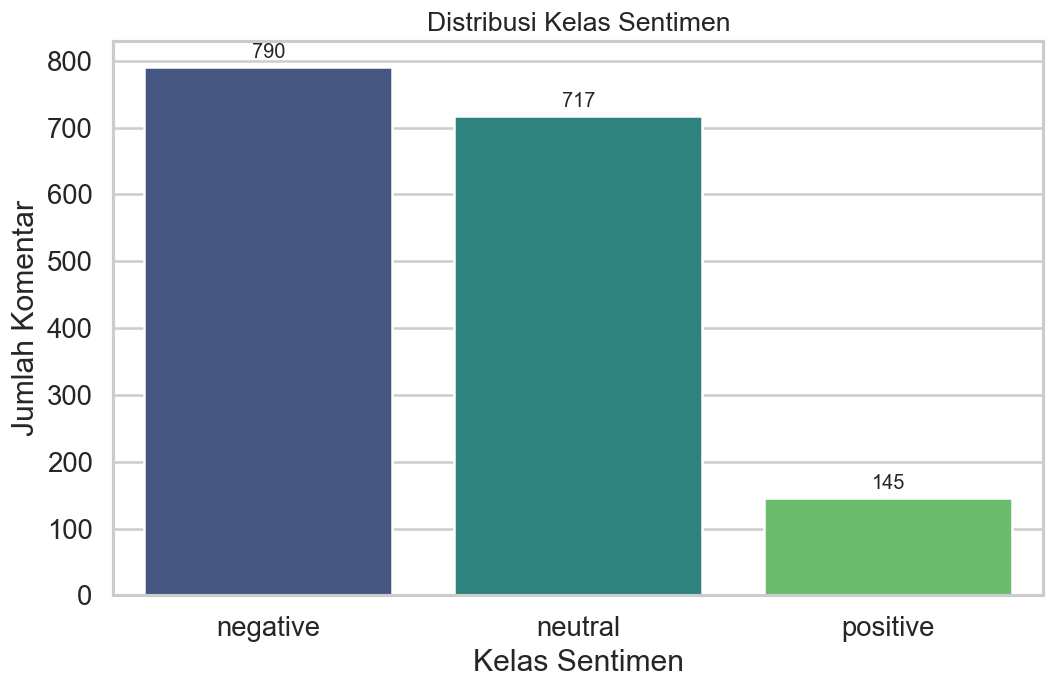

Gambar tersimpan pada: d:\sentimen-LTSM\figures\distribusi_kelas_batang.png


In [73]:
# Cell 6.1 - Visualisasi distribusi kelas dengan grafik batang
# Distribusi kelas mula-mula disajikan dalam bentuk grafik batang agar jumlah observasi pada setiap
# kategori sentimen dapat dibaca secara langsung. Visualisasi ini memberikan dasar kuantitatif yang
# jelas untuk menilai tingkat ketimpangan kelas sebelum eksperimen pembelajaran dilakukan.

label_order = ['negative', 'neutral', 'positive']
class_counts = df['label'].value_counts().reindex(label_order, fill_value=0)

plt.figure(figsize=(10, 6))
ax = sns.barplot(x=class_counts.index, y=class_counts.values, palette='viridis')
ax.set_title('Distribusi Kelas Sentimen', fontsize=16)
ax.set_xlabel('Kelas Sentimen')
ax.set_ylabel('Jumlah Komentar')
for idx, value in enumerate(class_counts.values):
    ax.text(idx, value + max(class_counts.values) * 0.01, f'{value:,}', ha='center', va='bottom', fontsize=12)
bar_path = save_figure('distribusi_kelas_batang.png')
plt.show()
print(f'Gambar tersimpan pada: {bar_path}')


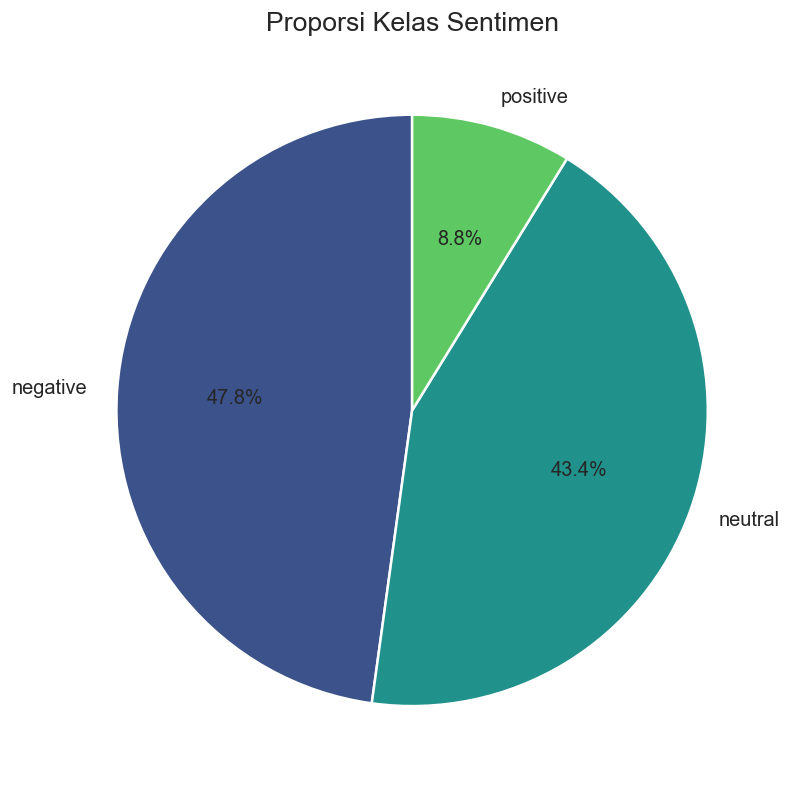

Gambar tersimpan pada: d:\sentimen-LTSM\figures\proporsi_kelas_pie_chart.png


In [74]:
# Cell 6.2 - Pie chart proporsi kelas
# Selain jumlah absolut, proporsi relatif antar kelas juga perlu ditampilkan agar gambaran struktur
# data menjadi lebih utuh. Pie chart melengkapi pembacaan distribusi dengan menekankan dominasi
# atau keterwakilan masing-masing kategori dalam keseluruhan korpus.

plt.figure(figsize=(8, 8))
colors = sns.color_palette('viridis', len(class_counts))
plt.pie(
    class_counts.values,
    labels=class_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    textprops={'fontsize': 12}
)
plt.title('Proporsi Kelas Sentimen', fontsize=16)
pie_path = save_figure('proporsi_kelas_pie_chart.png')
plt.show()
print(f'Gambar tersimpan pada: {pie_path}')


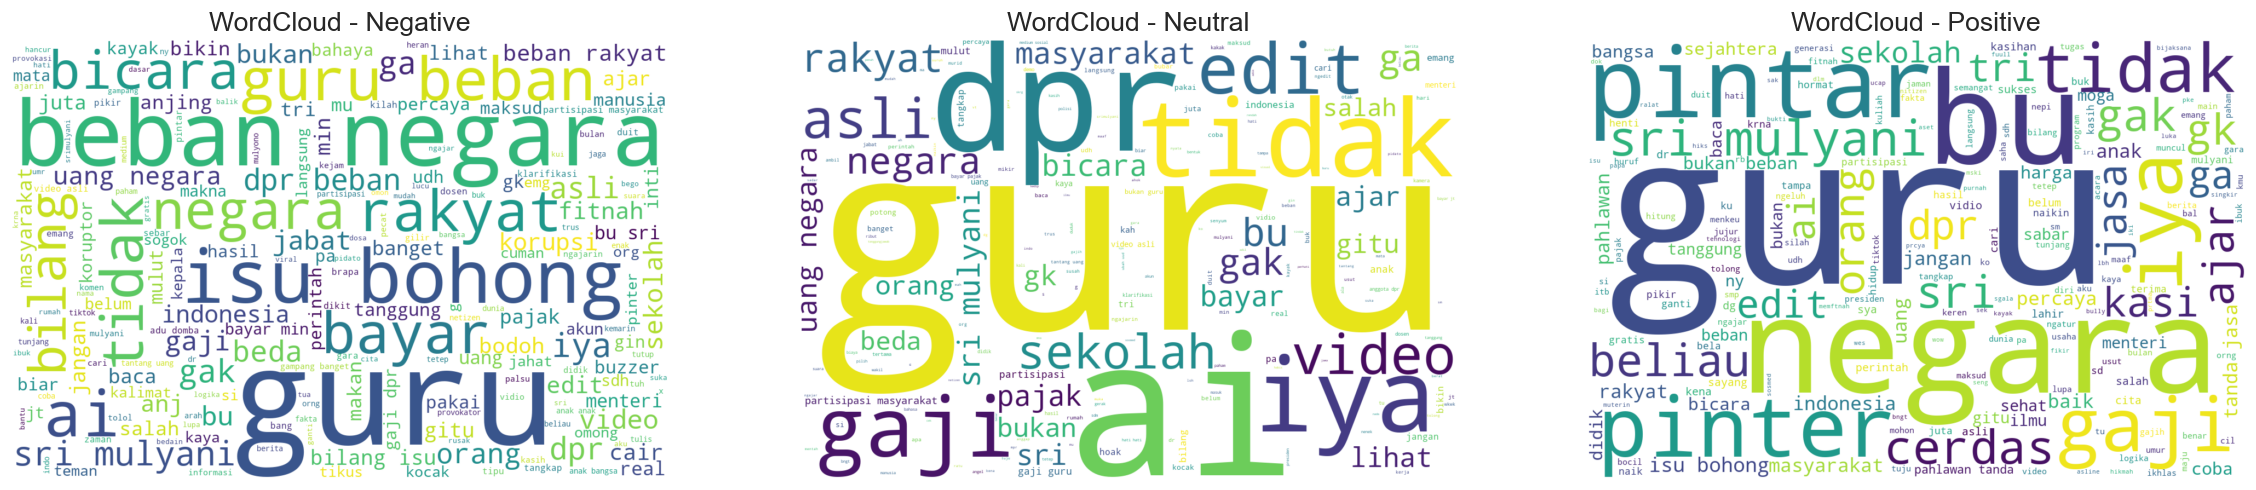

Gambar tersimpan pada: d:\sentimen-LTSM\figures\wordcloud_per_kelas.png


In [75]:
# Cell 6.3 - WordCloud untuk setiap kelas sentimen
# Pada tahap berikutnya, karakter leksikal tiap kelas divisualisasikan melalui WordCloud. Meskipun
# bersifat pelengkap, visualisasi ini membantu memperlihatkan kecenderungan kosakata yang dominan
# pada masing-masing kelompok sentimen sehingga interpretasi hasil menjadi lebih kontekstual.

fig, axes = plt.subplots(1, 3, figsize=(24, 8))
for idx, label in enumerate(label_order):
    class_text = ' '.join(df.loc[df['label'] == label, 'text_final'])
    if not class_text.strip():
        class_text = 'data tidak tersedia'
    wc = WordCloud(width=1200, height=800, background_color='white', colormap='viridis').generate(class_text)
    axes[idx].imshow(wc, interpolation='bilinear')
    axes[idx].set_title(f'WordCloud - {label.title()}', fontsize=16)
    axes[idx].axis('off')
wordcloud_path = save_figure('wordcloud_per_kelas.png')
plt.show()
print(f'Gambar tersimpan pada: {wordcloud_path}')


In [76]:
# Cell 7 - Label encoding target
# Agar kelas sentimen dapat diproses oleh model klasifikasi, label kategorikal diubah ke bentuk
# numerik dengan urutan yang tetap. Penetapan ini penting karena konsistensi pemetaan label akan
# memengaruhi interpretasi keluaran model, evaluasi, dan implementasi prediksi pada tahap akhir.

label_to_int = {'negative': 0, 'neutral': 1, 'positive': 2}
int_to_label = {value: key for key, value in label_to_int.items()}
df['label_int'] = df['label'].map(label_to_int)

display(df[['text_final', 'label', 'label_int']].head())
print('Pemetaan label numerik:', label_to_int)


,text_final,label,label_int
0,kilah,negative,0
1,tolong usut edit vidio tangkap,neutral,1
2,lihat real lihat mulut,neutral,1
3,video asli muncul beliau undur dr jabat,neutral,1
4,hoak ai maksud suka bikin vidio ai kali,neutral,1


Pemetaan label numerik: {'negative': 0, 'neutral': 1, 'positive': 2}


In [77]:
# Cell 8 - Train-test split
# Pemisahan data dilakukan sebelum pembentukan representasi numerik dan balancing untuk menjaga
# validitas evaluasi. Dengan demikian, seluruh proses pembelajaran berlangsung hanya pada data
# latih, sedangkan data uji dipertahankan sebagai acuan independen dalam menilai kemampuan
# generalisasi model.

model_columns = ['text_raw', 'text_final', 'tokens_final', 'label', 'label_int']
df_model = df[model_columns].copy().reset_index(drop=True)

train_df, test_df = train_test_split(
    df_model,
    test_size=0.20,
    stratify=df_model['label_int'],
    random_state=RANDOM_STATE
)

train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

X_train_text = train_df['text_final'].tolist()
X_test_text = test_df['text_final'].tolist()
X_train_tokens = train_df['tokens_final'].tolist()
X_test_tokens = test_df['tokens_final'].tolist()
y_train_int = train_df['label_int'].to_numpy()
y_test_int = test_df['label_int'].to_numpy()

print(f'Ukuran data latih: {len(train_df):,}')
print(f'Ukuran data uji: {len(test_df):,}')
display(train_df.head())


Ukuran data latih: 1,321
Ukuran data uji: 331


,text_raw,text_final,tokens_final,label,label_int
0,tunggu bu 😅 giliran nya,tunggu bu gilir,"[tunggu, bu, gilir]",negative,0
1,ditimpa cik😹,timpa cik,"[timpa, cik]",negative,0
2,"dibayarr ini fix, kaya bandar kmrn wkwk",dibayarr fix kaya bandar kemarin wkwk,"[dibayarr, fix, kaya, bandar, kemarin, wkwk]",neutral,1
3,tanpa guru dia hanya ibu ibu yang ngantri sembako,guru antri sembilan bahan pokok,"[guru, antri, sembilan, bahan, pokok]",negative,0
4,Sri,sri,[sri],neutral,1


In [78]:
# Cell 9.1 - Siapkan korpus Word2Vec
# Atas dasar data latih yang telah dipisahkan, korpus Word2Vec disusun dari token-token yang siap
# dipelajari konteksnya. Statistik panjang dokumen turut dihitung untuk memberikan gambaran awal
# mengenai karakter korpus yang akan membentuk representasi semantik bagi tahap pemodelan
# berikutnya.

train_lengths = [len(tokens) for tokens in X_train_tokens]
test_lengths = [len(tokens) for tokens in X_test_tokens]

length_summary = pd.DataFrame({
    'subset': ['train', 'test'],
    'jumlah_dokumen': [len(train_lengths), len(test_lengths)],
    'rata_rata_panjang': [np.mean(train_lengths), np.mean(test_lengths)],
    'median_panjang': [np.median(train_lengths), np.median(test_lengths)],
    'panjang_maksimum': [np.max(train_lengths), np.max(test_lengths)]
})

display(length_summary)


,subset,jumlah_dokumen,rata_rata_panjang,median_panjang,panjang_maksimum
0,train,1321,5.917487,4.0,125
1,test,331,6.350453,4.0,78


In [79]:
# Cell 9.2 - Latih model Word2Vec
# Word2Vec kemudian dilatih pada korpus data latih agar hubungan antarkata dipelajari langsung dari
# konteks percakapan yang relevan dengan isu penelitian. Pemilihan parameter dilakukan secara
# moderat dengan mempertimbangkan ukuran dataset, sehingga model tetap informatif tanpa menjadi
# terlalu kompleks.

W2V_VECTOR_SIZE = 100
W2V_WINDOW = 5
W2V_MIN_COUNT = 1
W2V_WORKERS = 4
W2V_EPOCHS = 30
W2V_SG = 1

w2v_model = Word2Vec(
    sentences=X_train_tokens,
    vector_size=W2V_VECTOR_SIZE,
    window=W2V_WINDOW,
    min_count=W2V_MIN_COUNT,
    workers=W2V_WORKERS,
    sg=W2V_SG,
    epochs=W2V_EPOCHS,
    seed=RANDOM_STATE
)

print('Pelatihan Word2Vec selesai.')
print(f'Ukuran vocabulary Word2Vec: {len(w2v_model.wv):,}')


Pelatihan Word2Vec selesai.
Ukuran vocabulary Word2Vec: 2,049


In [80]:
# Cell 9.3 - Perhitungan representasi Word2Vec
# Karakter representasi yang dihasilkan didokumentasikan melalui ukuran kosakata, contoh vektor,
# kemiripan kosinus, dan daftar kata terdekat. Penjabaran ini penting karena pembobotan Word2Vec
# tidak hanya berfungsi teknis sebagai input model, tetapi juga memiliki makna semantik yang dapat
# diinterpretasikan.

vocab_words = list(w2v_model.wv.index_to_key)
candidate_words = [word for word in ['hoax', 'deepfake', 'ai', 'video', 'guru'] if word in w2v_model.wv]
if len(candidate_words) < 2:
    candidate_words = vocab_words[:5]

sample_word = candidate_words[0]
sample_vector = w2v_model.wv[sample_word][:10]

similarity_matrix = cosine_similarity([w2v_model.wv[word] for word in candidate_words])
similarity_df = pd.DataFrame(similarity_matrix, index=candidate_words, columns=candidate_words)

nearest_neighbors = []
for word in candidate_words[:3]:
    for neighbor, score in w2v_model.wv.most_similar(word, topn=min(5, len(w2v_model.wv) - 1)):
        nearest_neighbors.append({'kata_acuan': word, 'kata_terdekat': neighbor, 'kemiripan': score})
nearest_neighbors_df = pd.DataFrame(nearest_neighbors)

print(f'Contoh kata acuan: {sample_word}')
print('Sepuluh komponen awal vektor contoh:')
print(sample_vector)
display(similarity_df.round(4))
display(nearest_neighbors_df.head(15))


Contoh kata acuan: hoax
Sepuluh komponen awal vektor contoh:
[ 0.02672412 -0.086302   -0.08288082 -0.06833927 -0.14412782  0.03041194
  0.01333241  0.07073382 -0.05380723 -0.0632618 ]


,hoax,deepfake,ai,video,guru
hoax,1.0000,0.9890,0.8049,0.7656,0.6707
deepfake,0.9890,1.0000,0.8158,0.7839,0.6637
ai,0.8049,0.8158,1.0000,0.9657,0.2691
video,0.7656,0.7839,0.9657,1.0000,0.1870
guru,0.6707,0.6637,0.2691,0.1870,1.0000


,kata_acuan,kata_terdekat,kemiripan
0,hoax,terjadipenggrudukan,0.994924
1,hoax,provokator,0.994881
2,hoax,aparat,0.994811
3,hoax,bgaimna,0.994762
4,hoax,anggar,0.994729
5,deepfake,kelit,0.994457
6,deepfake,minim,0.993587
7,deepfake,bbrp,0.993418
8,deepfake,bnyak,0.993281
9,deepfake,sasar,0.993201


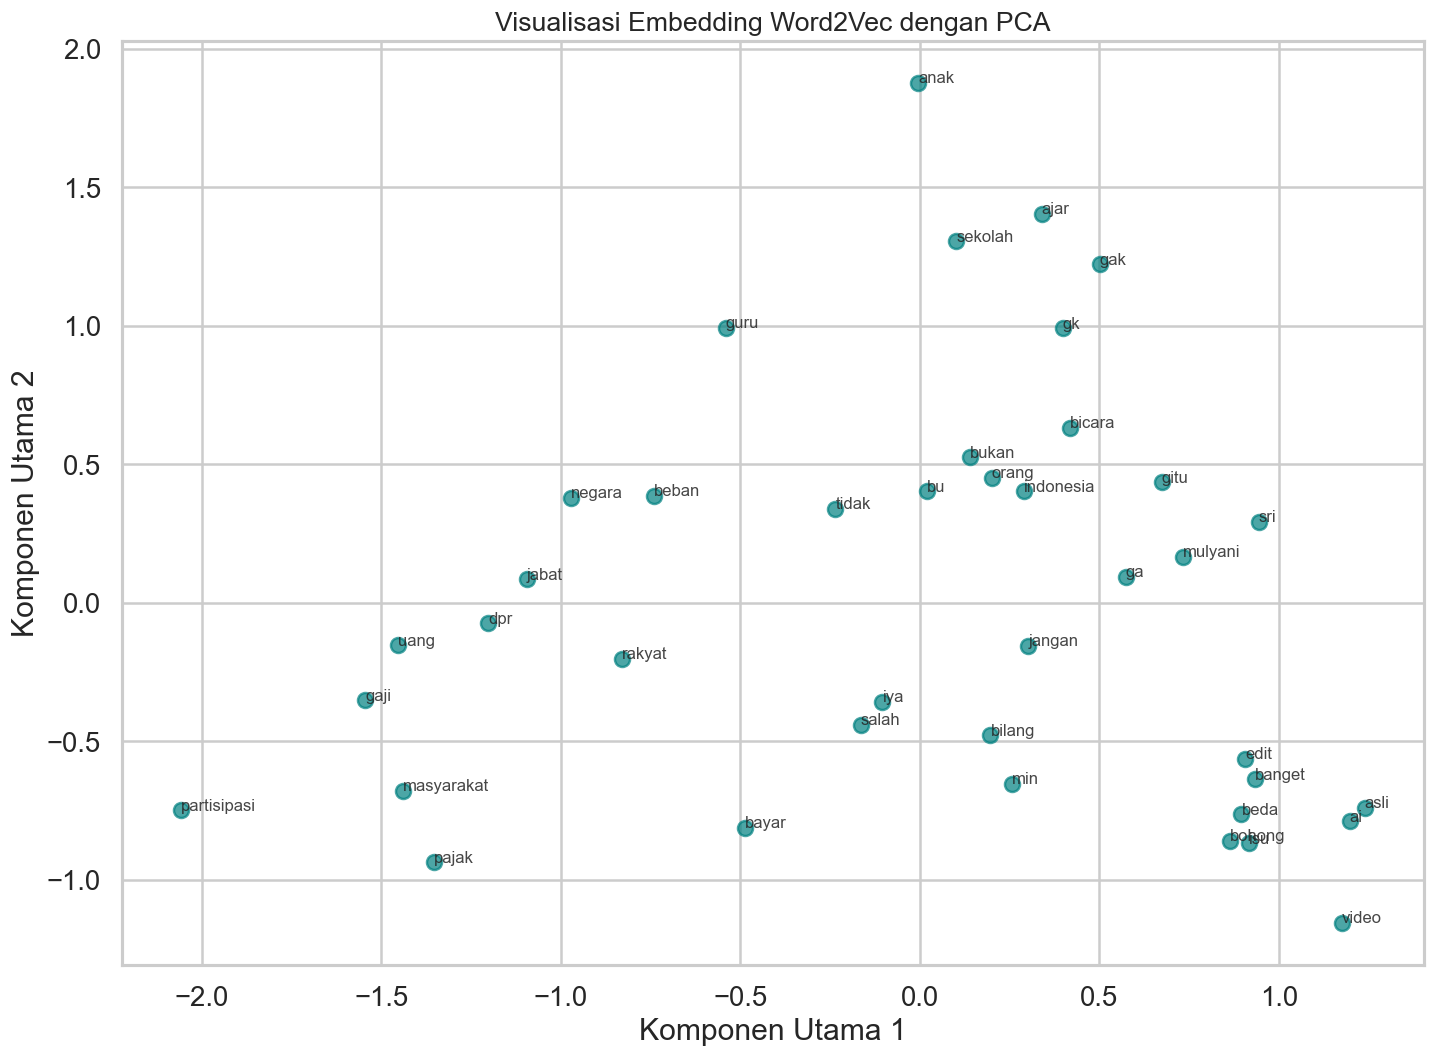

Gambar tersimpan pada: d:\sentimen-LTSM\figures\visualisasi_word2vec_pca.png


In [81]:
# Cell 9.4 - Visualisasi embedding Word2Vec
# Untuk memperjelas struktur semantik yang terbentuk, sejumlah vektor kata diproyeksikan ke dua
# dimensi. Visualisasi ini tidak digunakan sebagai dasar tunggal penarikan kesimpulan, tetapi
# membantu menunjukkan kecenderungan kedekatan spasial antarkata yang dominan dalam korpus
# penelitian.

token_counter = Counter([token for tokens in X_train_tokens for token in tokens])
top_words = [word for word, _ in token_counter.most_common(min(40, len(token_counter)))]
word_vectors = np.array([w2v_model.wv[word] for word in top_words])
pca = PCA(n_components=2, random_state=RANDOM_STATE)
word_vectors_2d = pca.fit_transform(word_vectors)

plt.figure(figsize=(14, 10))
plt.scatter(word_vectors_2d[:, 0], word_vectors_2d[:, 1], color='teal', alpha=0.7)
for i, word in enumerate(top_words):
    plt.annotate(word, (word_vectors_2d[i, 0], word_vectors_2d[i, 1]), fontsize=10, alpha=0.85)
plt.title('Visualisasi Embedding Word2Vec dengan PCA', fontsize=16)
plt.xlabel('Komponen Utama 1')
plt.ylabel('Komponen Utama 2')
w2v_pca_path = save_figure('visualisasi_word2vec_pca.png')
plt.show()
print(f'Gambar tersimpan pada: {w2v_pca_path}')


In [82]:
# Cell 9.5 - Tokenizer, sequence, dan padding
# Setelah relasi antarkata direpresentasikan, teks diubah menjadi urutan indeks agar dapat diproses
# oleh LSTM. Penetapan panjang sequence dilakukan dengan mempertimbangkan sebaran panjang dokumen
# pada data latih sehingga keseimbangan antara efisiensi komputasi dan pemeliharaan konteks tetap
# terjaga.

tokenizer = Tokenizer(oov_token='<OOV>')
tokenizer.fit_on_texts(X_train_text)

X_train_seq = tokenizer.texts_to_sequences(X_train_text)
X_test_seq = tokenizer.texts_to_sequences(X_test_text)

sequence_lengths = [len(seq) for seq in X_train_seq if len(seq) > 0]
MAX_SEQUENCE_LENGTH = int(np.clip(np.percentile(sequence_lengths, 95), a_min=5, a_max=100))

X_train_padded = pad_sequences(X_train_seq, maxlen=MAX_SEQUENCE_LENGTH, padding='post', truncating='post')
X_test_padded = pad_sequences(X_test_seq, maxlen=MAX_SEQUENCE_LENGTH, padding='post', truncating='post')

sequence_summary = pd.DataFrame({
    'statistik': ['rata-rata', 'median', 'maksimum', 'maxlen_digunakan'],
    'nilai': [np.mean(sequence_lengths), np.median(sequence_lengths), np.max(sequence_lengths), MAX_SEQUENCE_LENGTH]
})

display(sequence_summary)
print(f'Bentuk matriks sequence data latih: {X_train_padded.shape}')
print(f'Bentuk matriks sequence data uji: {X_test_padded.shape}')


,statistik,nilai
0,rata-rata,5.917487
1,median,4.000000
2,maksimum,125.000000
3,maxlen_digunakan,16.000000


Bentuk matriks sequence data latih: (1321, 16)
Bentuk matriks sequence data uji: (331, 16)


In [83]:
# Cell 9.6 - Bangun embedding matrix
# Embedding matrix dibentuk untuk menyelaraskan tokenizer dengan representasi Word2Vec yang telah
# dipelajari. Pada titik ini, setiap indeks token dihubungkan dengan vektor awal yang konsisten,
# sementara tingkat cakupan kosakata dihitung untuk menilai seberapa jauh vocabulary tokenizer
# berhasil dipetakan ke ruang embedding.

VOCAB_SIZE = len(tokenizer.word_index) + 1
EMBEDDING_DIM = w2v_model.vector_size

embedding_matrix = np.random.normal(loc=0.0, scale=0.05, size=(VOCAB_SIZE, EMBEDDING_DIM)).astype(np.float32)
embedding_matrix[0] = np.zeros((EMBEDDING_DIM,), dtype=np.float32)

covered_words = 0
for word, index in tokenizer.word_index.items():
    if word in w2v_model.wv:
        embedding_matrix[index] = w2v_model.wv[word]
        covered_words += 1

coverage_ratio = covered_words / max(1, VOCAB_SIZE - 1)
coverage_df = pd.DataFrame({
    'ukuran_vocabulary_tokenizer': [VOCAB_SIZE - 1],
    'kata_tercakup_word2vec': [covered_words],
    'rasio_cakupan': [coverage_ratio]
})

display(coverage_df)


,ukuran_vocabulary_tokenizer,kata_tercakup_word2vec,rasio_cakupan
0,2050,2049,0.999512


In [32]:
# Cell 10.1 - Distribusi kelas pada data latih sebelum balancing
# Sebelum balancing diterapkan, distribusi kelas pada data latih ditinjau kembali agar sumber
# ketimpangan dapat diidentifikasi secara spesifik. Pemeriksaan ini penting karena intervensi
# balancing hanya layak dilakukan pada data latih, sedangkan data uji harus tetap merefleksikan
# distribusi alami.

train_class_counts = pd.Series(y_train_int).value_counts().sort_index()
train_class_df = pd.DataFrame({
    'kelas_int': train_class_counts.index,
    'kelas_label': [int_to_label[idx] for idx in train_class_counts.index],
    'jumlah': train_class_counts.values
})
display(train_class_df)


,kelas_int,kelas_label,jumlah
0,0,negative,207
1,1,neutral,696
2,2,positive,421


In [84]:
# Cell 10.2 - Siapkan cabang eksperimen tanpa balancing
# Cabang pertama diposisikan sebagai baseline yang merepresentasikan pembelajaran pada distribusi
# data latih apa adanya. Keberadaan baseline ini diperlukan agar pengaruh balancing terhadap kinerja
# model dapat dievaluasi melalui perbandingan yang terkontrol dan metodologis.

NUM_CLASSES = len(label_to_int)

X_train_unbalanced = X_train_padded.copy()
y_train_unbalanced_int = y_train_int.copy()
y_train_unbalanced_cat = to_categorical(y_train_unbalanced_int, num_classes=NUM_CLASSES)
y_test_cat = to_categorical(y_test_int, num_classes=NUM_CLASSES)

print(f'Bentuk data latih tanpa balancing: {X_train_unbalanced.shape}')


Bentuk data latih tanpa balancing: (1321, 16)


In [85]:
# Cell 10.3 - Terapkan balancing pada data latih
# Cabang kedua menerapkan balancing berbasis RandomOverSampler pada data latih. Pendekatan ini
# dimaksudkan untuk memperkuat keterwakilan kelas minoritas tanpa mengubah distribusi data uji,
# sehingga perbedaan performa yang muncul pada tahap evaluasi dapat ditafsirkan sebagai dampak
# dari intervensi balancing.

ros = RandomOverSampler(random_state=RANDOM_STATE)
X_train_balanced, y_train_balanced_int = ros.fit_resample(X_train_padded, y_train_int)
y_train_balanced_cat = to_categorical(y_train_balanced_int, num_classes=NUM_CLASSES)

balanced_class_counts = pd.Series(y_train_balanced_int).value_counts().sort_index()
balanced_class_df = pd.DataFrame({
    'kelas_int': balanced_class_counts.index,
    'kelas_label': [int_to_label[idx] for idx in balanced_class_counts.index],
    'jumlah': balanced_class_counts.values
})

display(balanced_class_df)
print(f'Bentuk data latih dengan balancing: {X_train_balanced.shape}')


,kelas_int,kelas_label,jumlah
0,0,negative,632
1,1,neutral,632
2,2,positive,632


Bentuk data latih dengan balancing: (1896, 16)


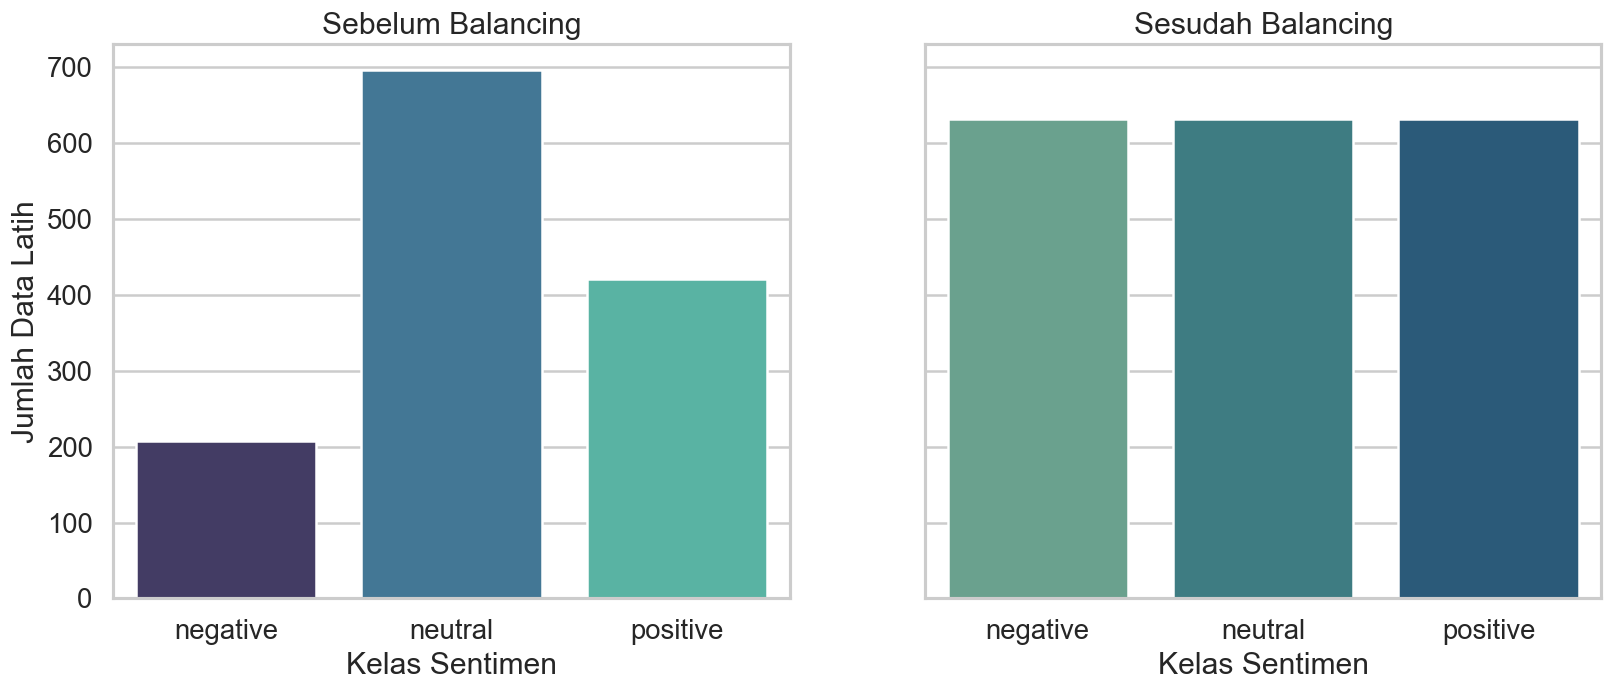

Gambar tersimpan pada: d:\sentimen-LTSM\figures\perbandingan_balancing_data_latih.png


In [86]:
# Cell 10.4 - Visualisasi sebelum dan sesudah balancing
# Perubahan struktur distribusi kelas kemudian divisualisasikan agar dampak balancing dapat diamati
# secara langsung. Dengan demikian, balancing tidak hanya hadir sebagai prosedur teknis, melainkan
# sebagai intervensi metodologis yang dapat diperiksa secara empiris.

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

sns.barplot(data=train_class_df, x='kelas_label', y='jumlah', palette='mako', ax=axes[0])
axes[0].set_title('Sebelum Balancing')
axes[0].set_xlabel('Kelas Sentimen')
axes[0].set_ylabel('Jumlah Data Latih')

sns.barplot(data=balanced_class_df, x='kelas_label', y='jumlah', palette='crest', ax=axes[1])
axes[1].set_title('Sesudah Balancing')
axes[1].set_xlabel('Kelas Sentimen')
axes[1].set_ylabel('Jumlah Data Latih')

balance_compare_path = save_figure('perbandingan_balancing_data_latih.png')
plt.show()
print(f'Gambar tersimpan pada: {balance_compare_path}')


In [87]:
# Cell 11.1 - Tetapkan parameter model LSTM
# Sesudah representasi data siap, konfigurasi model LSTM dinyatakan secara eksplisit melalui
# seperangkat hiperparameter. Pendokumentasian ini penting untuk menjaga keterlacakan keputusan
# eksperimental serta memungkinkan reproduksi hasil pada pengujian berikutnya.

MODEL_PARAMS = {
    'vocab_size': VOCAB_SIZE,
    'embedding_dim': EMBEDDING_DIM,
    'max_sequence_length': MAX_SEQUENCE_LENGTH,
    'lstm_units': 128,
    'dense_units': 64,
    'dropout_rate': 0.4,
    'learning_rate': 1e-3,
    'batch_size': 32,
    'epochs': 20,
    'patience': 4,
    'num_classes': NUM_CLASSES,
    'validation_split': 0.2
}

display(pd.DataFrame(MODEL_PARAMS.items(), columns=['parameter', 'nilai']))


,parameter,nilai
0,vocab_size,2051.000
1,embedding_dim,100.000
2,max_sequence_length,16.000
3,lstm_units,128.000
4,dense_units,64.000
5,dropout_rate,0.400
6,learning_rate,0.001
7,batch_size,32.000
8,epochs,20.000
9,patience,4.000


In [88]:
# Cell 11.2 - Definisikan arsitektur model LSTM
# Arsitektur model dibangun dengan memadukan lapisan embedding, regularisasi, pemodelan urutan,
# dan klasifikasi akhir. Susunan ini menegaskan hubungan antara representasi Word2Vec yang telah
# dipelajari sebelumnya dan mekanisme LSTM yang digunakan untuk mengenali pola sentimen dalam
# urutan kata.

def build_lstm_model():
    model = Sequential([
        Embedding(
            input_dim=MODEL_PARAMS['vocab_size'],
            output_dim=MODEL_PARAMS['embedding_dim'],
            weights=[embedding_matrix],
            input_length=MODEL_PARAMS['max_sequence_length'],
            trainable=True
        ),
        SpatialDropout1D(0.2),
        LSTM(MODEL_PARAMS['lstm_units'], dropout=MODEL_PARAMS['dropout_rate']),
        Dense(MODEL_PARAMS['dense_units'], activation='relu'),
        Dropout(MODEL_PARAMS['dropout_rate']),
        Dense(MODEL_PARAMS['num_classes'], activation='softmax')
    ])
    model.compile(
        optimizer=Adam(learning_rate=MODEL_PARAMS['learning_rate']),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

reference_model = build_lstm_model()
reference_model.summary()


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │       205,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_3             │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 205,100 (801.17 KB)

 Trainable params: 205,100 (801.17 KB)

 Non-trainable params: 0 (0.00 B)

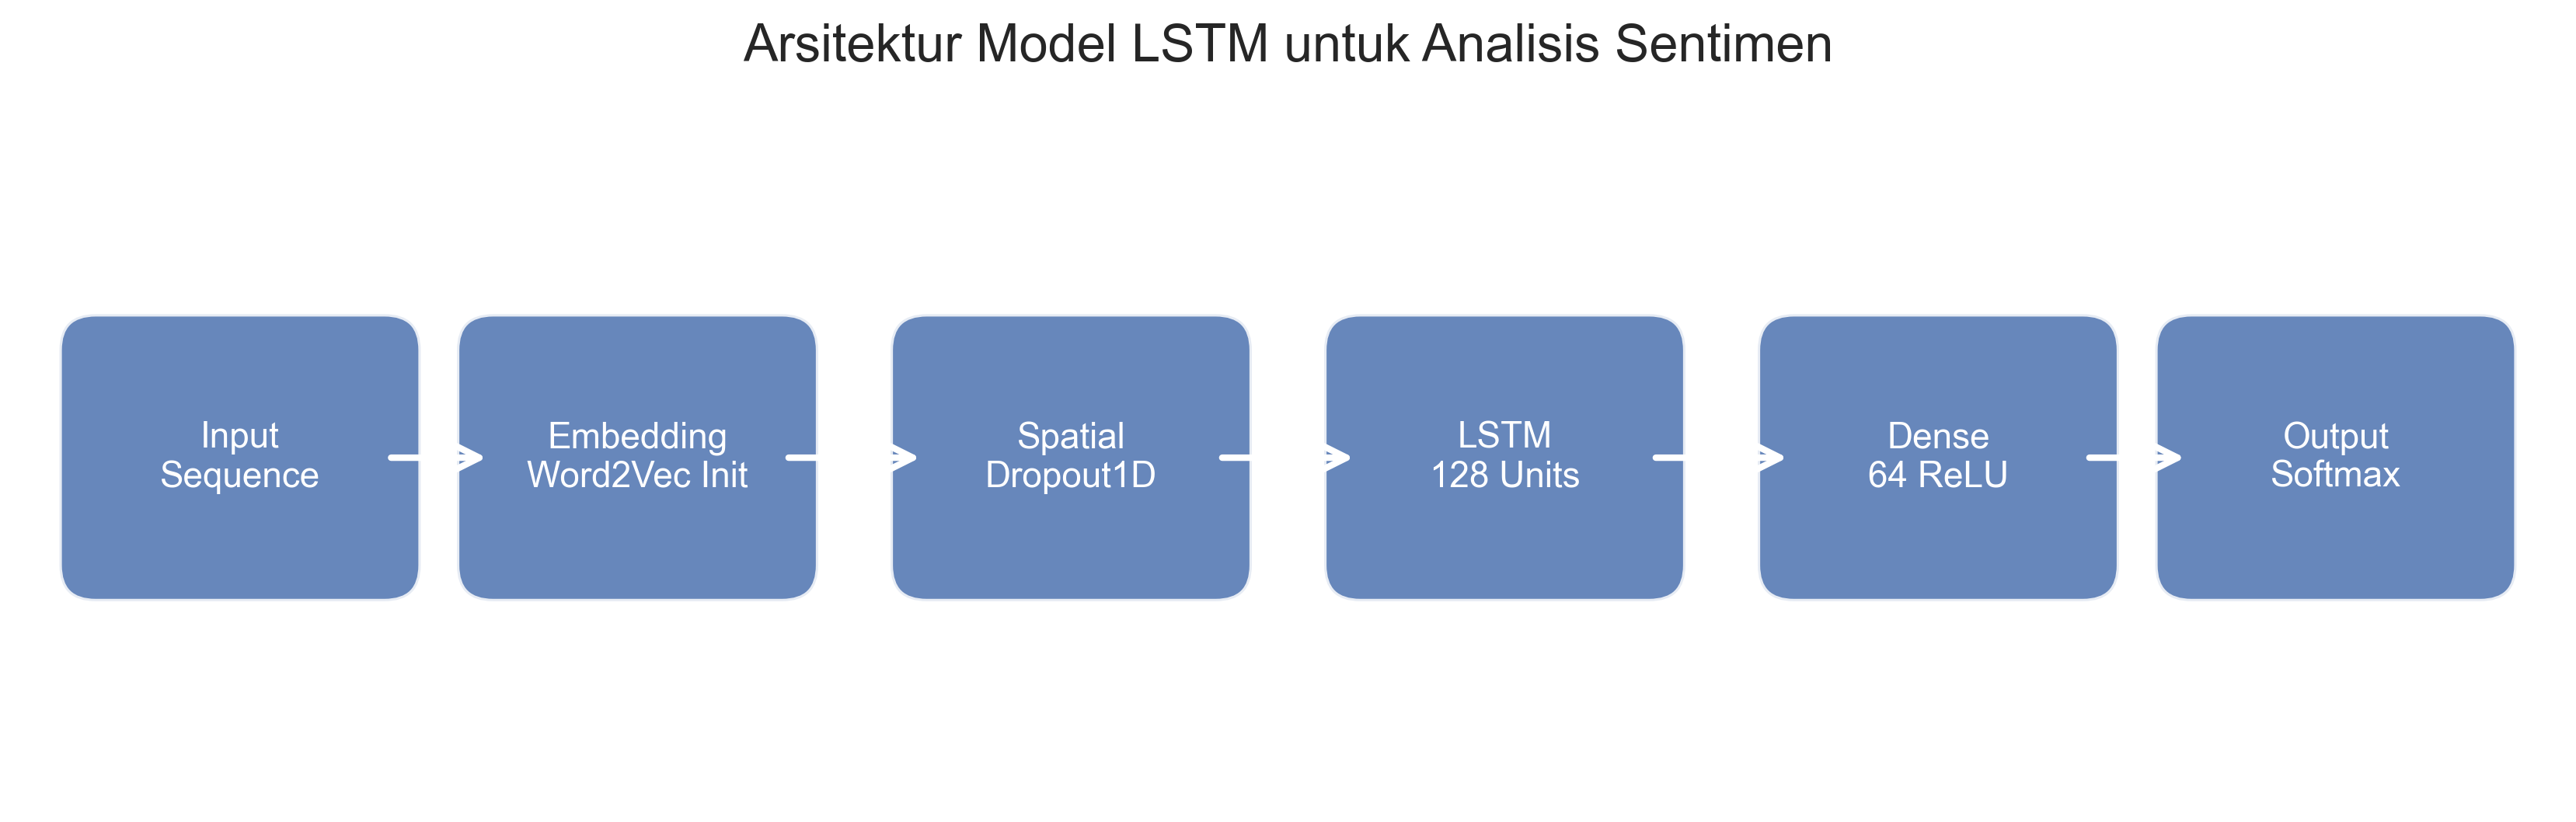

Gambar tersimpan pada: d:\sentimen-LTSM\figures\arsitektur_model_lstm.png


In [89]:
# Cell 11.3 - Simpan gambar arsitektur model
# Dokumentasi visual terhadap arsitektur model diperlukan untuk kepentingan pelaporan ilmiah. Oleh
# karena itu, diagram model dihasilkan secara otomatis apabila utilitas yang diperlukan tersedia,
# dan apabila tidak tersedia, representasi visual alternatif tetap disiapkan agar struktur model
# dapat dijelaskan secara memadai.

architecture_path = FIG_DIR / 'arsitektur_model_lstm.png'
try:
    plot_model(reference_model, to_file=str(architecture_path), show_shapes=True, show_layer_names=True, dpi=300)
except Exception:
    from matplotlib.patches import FancyBboxPatch
    plt.figure(figsize=(14, 4))
    ax = plt.gca()
    ax.set_xlim(0, 14)
    ax.set_ylim(0, 4)
    ax.axis('off')
    layer_specs = [
        (0.4, 'Input\nSequence'),
        (2.6, 'Embedding\nWord2Vec Init'),
        (5.0, 'Spatial\nDropout1D'),
        (7.4, 'LSTM\n128 Units'),
        (9.8, 'Dense\n64 ReLU'),
        (12.0, 'Output\nSoftmax')
    ]
    for x_pos, label in layer_specs:
        patch = FancyBboxPatch((x_pos, 1.3), 1.6, 1.2, boxstyle='round,pad=0.2', facecolor='#4C72B0', alpha=0.85)
        ax.add_patch(patch)
        ax.text(x_pos + 0.8, 1.9, label, ha='center', va='center', color='white', fontsize=11)
    for i in range(len(layer_specs) - 1):
        ax.annotate('', xy=(layer_specs[i + 1][0], 1.9), xytext=(layer_specs[i][0] + 1.6, 1.9), arrowprops=dict(arrowstyle='->', lw=2))
    plt.title('Arsitektur Model LSTM untuk Analisis Sentimen', fontsize=16)
    plt.savefig(architecture_path, dpi=300, bbox_inches='tight')
    plt.close()

display(Image(filename=str(architecture_path)))
print(f'Gambar tersimpan pada: {architecture_path}')


In [90]:
# Cell 12.1 - Pelatihan model tanpa balancing
# Pelatihan pertama dilakukan pada data latih asli tanpa intervensi balancing. Hasilnya berfungsi
# sebagai acuan awal untuk menilai bagaimana distribusi kelas yang tidak disesuaikan memengaruhi
# kemampuan model dalam mempelajari pola sentimen dan melakukan generalisasi.

callbacks_unbalanced = [
    EarlyStopping(monitor='val_loss', patience=MODEL_PARAMS['patience'], restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, verbose=1)
]

model_unbalanced = build_lstm_model()
history_unbalanced = model_unbalanced.fit(
    X_train_unbalanced,
    y_train_unbalanced_cat,
    validation_split=MODEL_PARAMS['validation_split'],
    epochs=MODEL_PARAMS['epochs'],
    batch_size=MODEL_PARAMS['batch_size'],
    callbacks=callbacks_unbalanced,
    verbose=1
)


Epoch 1/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.4593 - loss: 0.9682 - val_accuracy: 0.4717 - val_loss: 0.9037 - learning_rate: 0.0010
Epoch 2/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.4583 - loss: 0.9261 - val_accuracy: 0.4792 - val_loss: 0.8984 - learning_rate: 0.0010
Epoch 3/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5057 - loss: 0.8972 - val_accuracy: 0.4943 - val_loss: 0.8951 - learning_rate: 0.0010
Epoch 4/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5720 - loss: 0.8137 - val_accuracy: 0.6302 - val_loss: 0.7873 - learning_rate: 0.0010
Epoch 5/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6496 - loss: 0.7589 - val_accuracy: 0.6491 - val_loss: 0.7526 - learning_rate: 0.0010
Epoch 6/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7169 - loss: 0.6846 - val_accuracy: 0.6302 - val_loss: 0.8576 - learning_rate: 0.0010
Epoch 7/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7244 - loss: 0.6572 - val_acc

In [91]:
# Cell 12.2 - Ringkasan history model tanpa balancing
# Riwayat pembelajaran model baseline kemudian dirangkum untuk memperlihatkan dinamika loss dan
# akurasi sepanjang proses pelatihan. Penyajian ini menjadi pijakan awal sebelum hasil tersebut
# dibandingkan dengan eksperimen kedua yang melibatkan balancing.

history_unbalanced_df = pd.DataFrame(history_unbalanced.history)
display(history_unbalanced_df.tail())


,accuracy,loss,val_accuracy,val_loss,learning_rate
7,0.787879,0.551742,0.690566,0.699675,0.0010
8,0.832386,0.467257,0.716981,0.769176,0.0010
9,0.826705,0.452631,0.698113,0.747495,0.0010
10,0.873106,0.365709,0.720755,0.801971,0.0005
11,0.876894,0.357385,0.728302,0.735455,0.0005


In [92]:
# Cell 13.1 - Pelatihan model dengan balancing
# Eksperimen kedua menggunakan arsitektur yang sama, tetapi dilatih pada data latih yang telah
# diseimbangkan. Karena faktor lain dipertahankan konstan, perbedaan hasil yang muncul dapat
# dibaca sebagai konsekuensi dari balancing terhadap proses pembelajaran model.

callbacks_balanced = [
    EarlyStopping(monitor='val_loss', patience=MODEL_PARAMS['patience'], restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, verbose=1)
]

model_balanced = build_lstm_model()
history_balanced = model_balanced.fit(
    X_train_balanced,
    y_train_balanced_cat,
    validation_split=MODEL_PARAMS['validation_split'],
    epochs=MODEL_PARAMS['epochs'],
    batch_size=MODEL_PARAMS['batch_size'],
    callbacks=callbacks_balanced,
    verbose=1
)


Epoch 1/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.4340 - loss: 1.0164 - val_accuracy: 0.4737 - val_loss: 1.2667 - learning_rate: 0.0010
Epoch 2/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.4657 - loss: 0.9544 - val_accuracy: 0.6211 - val_loss: 1.1177 - learning_rate: 0.0010
Epoch 3/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.5442 - loss: 0.8924 - val_accuracy: 0.5447 - val_loss: 1.0269 - learning_rate: 0.0010
Epoch 4/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.6392 - loss: 0.7738 - val_accuracy: 0.7237 - val_loss: 0.7905 - learning_rate: 0.0010
Epoch 5/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.7197 - loss: 0.6518 - val_accuracy: 0.9026 - val_loss: 0.2834 - learning_rate: 0.0010
Epoch 6/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.7540 - loss: 0.5631 - val_accuracy: 0.8737 - val_loss: 0.3628 - learning_rate: 0.0010
Epoch 7/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8130 - loss: 0.5084
Epoch 7: R

In [93]:
# Cell 13.2 - Ringkasan history model dengan balancing
# Riwayat pembelajaran untuk model yang dibalanskan disajikan dalam format yang seragam agar
# pembandingan terhadap model baseline dapat dilakukan secara langsung. Keseragaman ini membantu
# menjaga kejelasan interpretasi pada tahap evaluasi komparatif.

history_balanced_df = pd.DataFrame(history_balanced.history)
display(history_balanced_df.tail())


,accuracy,loss,val_accuracy,val_loss,learning_rate
15,0.896438,0.272095,0.957895,0.135987,0.00025
16,0.904354,0.281080,0.968421,0.129801,0.00025
17,0.909631,0.272457,0.944737,0.158767,0.00025
18,0.916227,0.257741,0.971053,0.115855,0.00025
19,0.906992,0.244892,0.971053,0.117076,0.00025


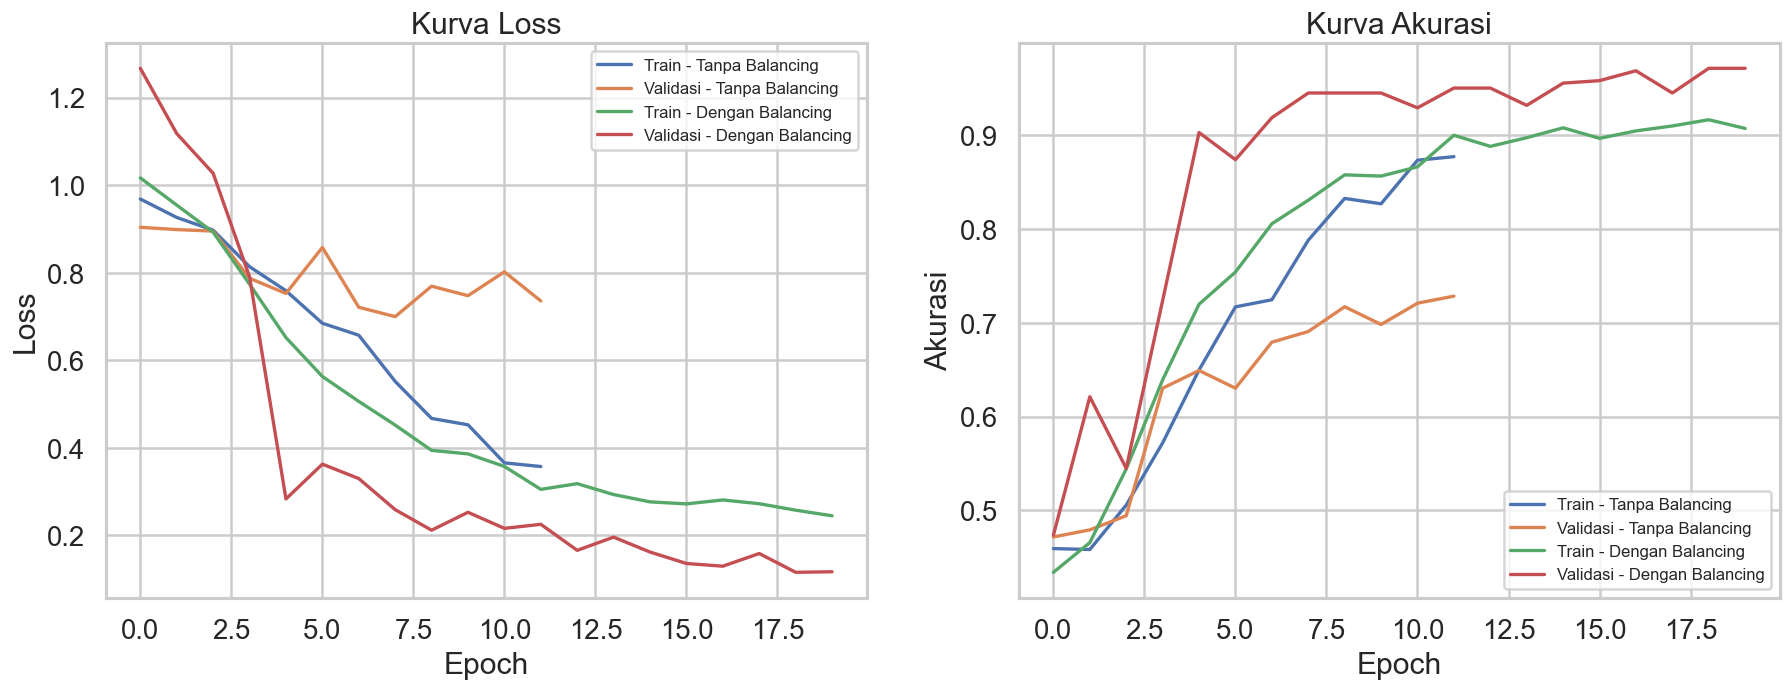

Gambar tersimpan pada: d:\sentimen-LTSM\figures\kurva_loss_akurasi_ablasi.png


In [94]:
# Cell 14.1 - Visualisasi kurva loss dan akurasi
# Kurva pembelajaran dari kedua eksperimen divisualisasikan untuk menunjukkan kestabilan proses
# optimisasi. Melalui perbandingan antara data pelatihan dan validasi, dapat diamati apakah
# balancing memperbaiki dinamika pembelajaran atau justru meningkatkan gejala overfitting.

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

axes[0].plot(history_unbalanced.history['loss'], label='Train - Tanpa Balancing', linewidth=2)
axes[0].plot(history_unbalanced.history['val_loss'], label='Validasi - Tanpa Balancing', linewidth=2)
axes[0].plot(history_balanced.history['loss'], label='Train - Dengan Balancing', linewidth=2)
axes[0].plot(history_balanced.history['val_loss'], label='Validasi - Dengan Balancing', linewidth=2)
axes[0].set_title('Kurva Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend(fontsize=10)

axes[1].plot(history_unbalanced.history['accuracy'], label='Train - Tanpa Balancing', linewidth=2)
axes[1].plot(history_unbalanced.history['val_accuracy'], label='Validasi - Tanpa Balancing', linewidth=2)
axes[1].plot(history_balanced.history['accuracy'], label='Train - Dengan Balancing', linewidth=2)
axes[1].plot(history_balanced.history['val_accuracy'], label='Validasi - Dengan Balancing', linewidth=2)
axes[1].set_title('Kurva Akurasi')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Akurasi')
axes[1].legend(fontsize=10)

curve_path = save_figure('kurva_loss_akurasi_ablasi.png')
plt.show()
print(f'Gambar tersimpan pada: {curve_path}')


,train_accuracy_akhir,train_loss_akhir,val_accuracy_terbaik,val_loss_minimum,epoch_efektif
tanpa_balancing,0.8769,0.3574,0.7283,0.6997,12
dengan_balancing,0.9070,0.2449,0.9711,0.1159,20


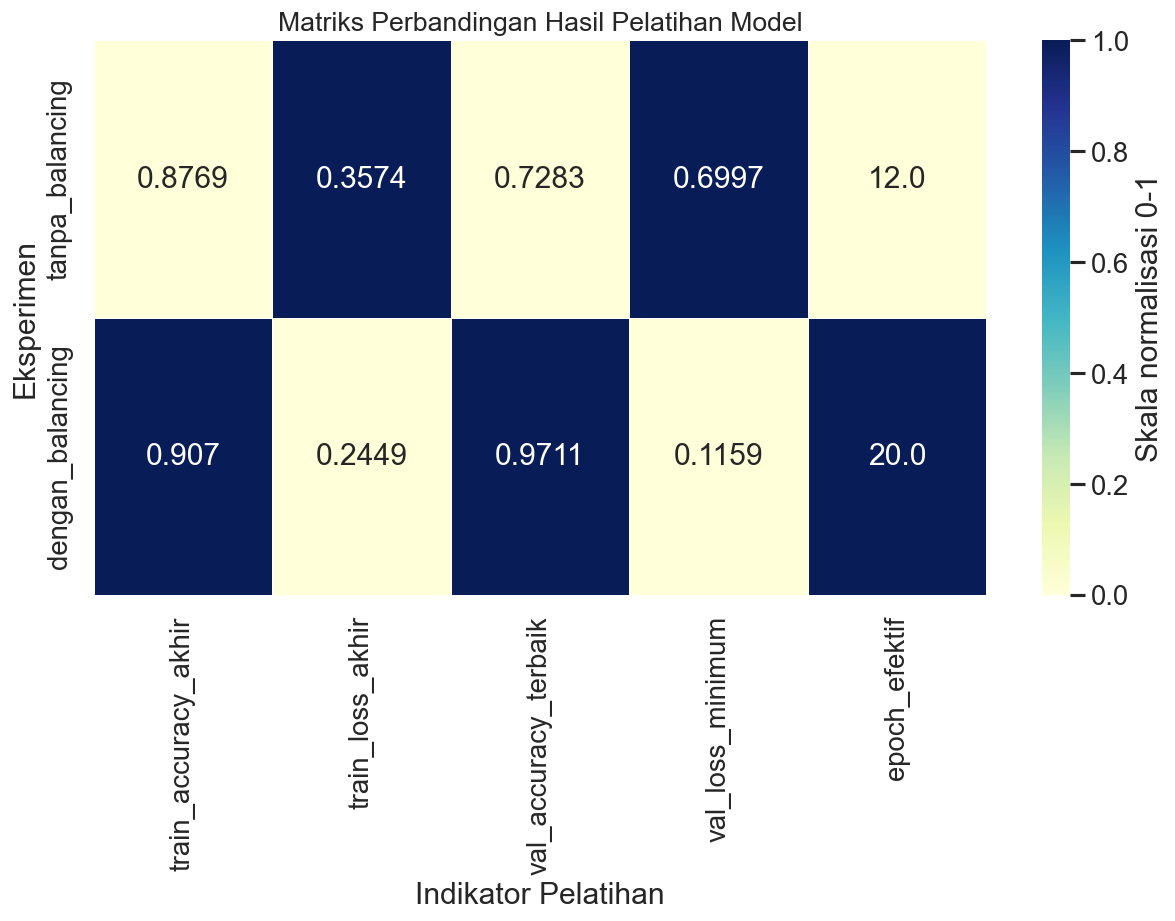

Gambar tersimpan pada: d:\sentimen-LTSM\figures\matriks_perbandingan_hasil_pelatihan.png


In [95]:
# Cell 14.1.1 - Visualisasi matriks perbandingan hasil pelatihan
# Setelah kurva pembelajaran ditinjau, hasil pelatihan kedua eksperimen diringkas dalam bentuk
# matriks agar perbedaan kinerja selama proses optimisasi dapat diamati secara lebih kompak.
# Ringkasan ini memuat indikator utama pelatihan, mencakup akurasi akhir, loss akhir, akurasi
# validasi terbaik, loss validasi minimum, dan jumlah epoch efektif yang dijalani masing-masing
# model.

training_comparison_df = pd.DataFrame({
    'train_accuracy_akhir': [history_unbalanced.history['accuracy'][-1], history_balanced.history['accuracy'][-1]],
    'train_loss_akhir': [history_unbalanced.history['loss'][-1], history_balanced.history['loss'][-1]],
    'val_accuracy_terbaik': [max(history_unbalanced.history['val_accuracy']), max(history_balanced.history['val_accuracy'])],
    'val_loss_minimum': [min(history_unbalanced.history['val_loss']), min(history_balanced.history['val_loss'])],
    'epoch_efektif': [len(history_unbalanced.history['loss']), len(history_balanced.history['loss'])]
}, index=['tanpa_balancing', 'dengan_balancing']).round(4)

display(training_comparison_df)

normalized_training_matrix = training_comparison_df.copy()
for column in normalized_training_matrix.columns:
    col_min = normalized_training_matrix[column].min()
    col_max = normalized_training_matrix[column].max()
    if col_max == col_min:
        normalized_training_matrix[column] = 1.0
    else:
        normalized_training_matrix[column] = (normalized_training_matrix[column] - col_min) / (col_max - col_min)

plt.figure(figsize=(12, 6))
ax = sns.heatmap(
    normalized_training_matrix,
    annot=training_comparison_df,
    fmt='',
    cmap='YlGnBu',
    linewidths=0.5,
    linecolor='white',
    cbar_kws={'label': 'Skala normalisasi 0-1'}
)
ax.set_title('Matriks Perbandingan Hasil Pelatihan Model', fontsize=16)
ax.set_xlabel('Indikator Pelatihan')
ax.set_ylabel('Eksperimen')
training_matrix_path = save_figure('matriks_perbandingan_hasil_pelatihan.png')
plt.show()
print(f'Gambar tersimpan pada: {training_matrix_path}')


,eksperimen,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,auc_macro_ovr
0,tanpa_balancing,0.6798,0.6315,0.6284,0.6268,0.6890,0.6798,0.6799,0.8010
1,dengan_balancing,0.7221,0.7722,0.6506,0.6845,0.7403,0.7221,0.7190,0.8422


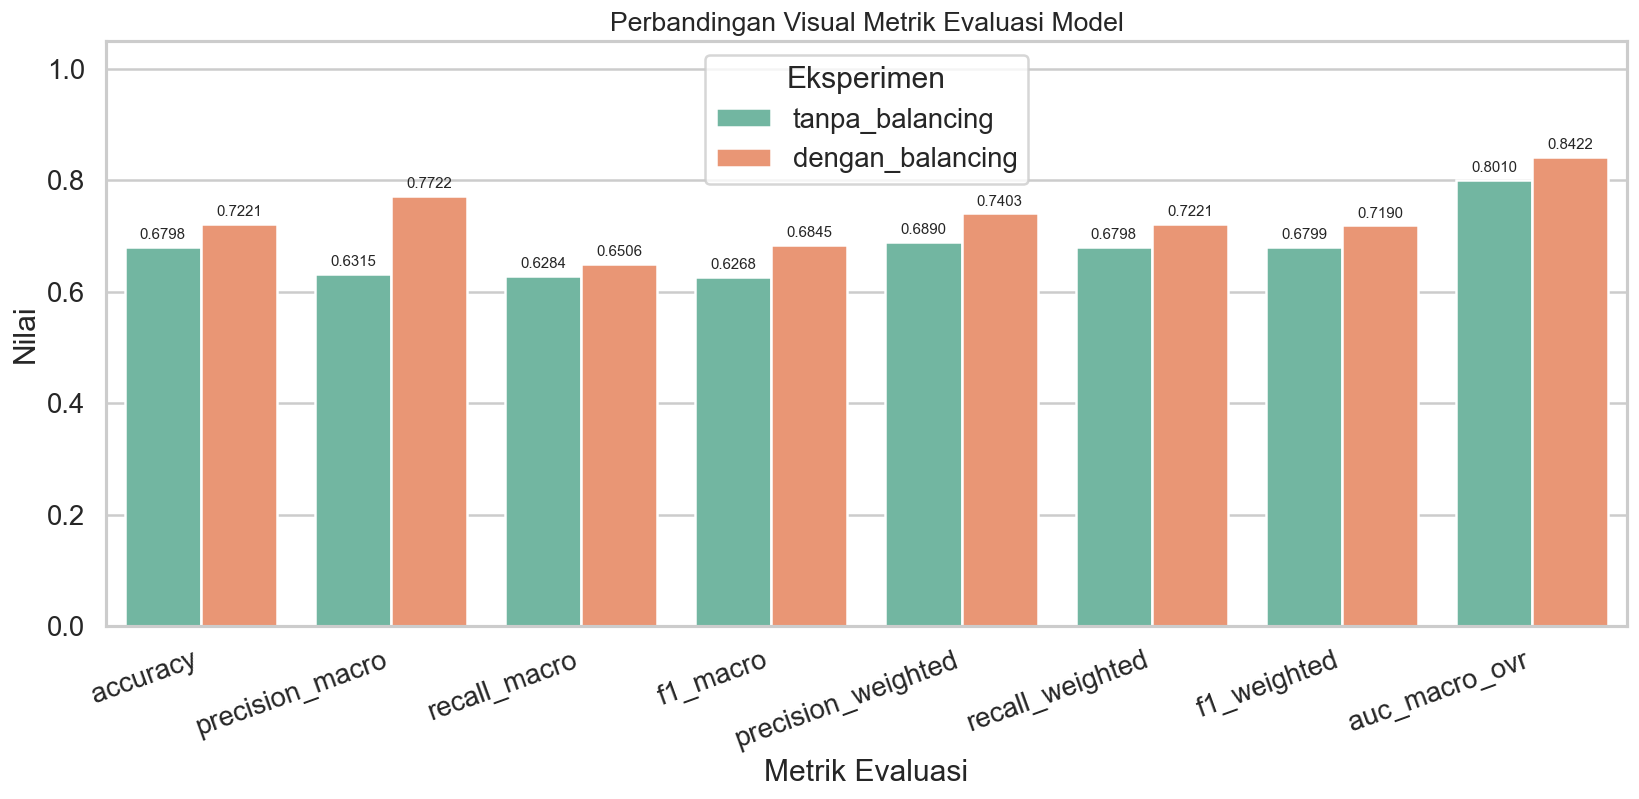

Gambar tersimpan pada: d:\sentimen-LTSM\figures\grafik_batang_metrik_evaluasi.png


In [96]:
# Cell 14.2 - Matriks evaluasi model LSTM
# Evaluasi kuantitatif pada data uji dilakukan dengan sejumlah metrik yang saling melengkapi,
# mencakup akurasi, presisi, recall, F1, dan AUC. Penggunaan beberapa metrik secara bersamaan
# memberikan dasar penilaian yang lebih seimbang, khususnya ketika struktur kelas tidak sepenuhnya
# homogen.

def evaluate_model(model, X_test, y_true_int, label_names):
    y_prob = model.predict(X_test, verbose=0)
    y_pred_int = np.argmax(y_prob, axis=1)
    y_true_bin = label_binarize(y_true_int, classes=list(range(len(label_names))))
    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        y_true_int, y_pred_int, average='macro', zero_division=0
    )
    precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(
        y_true_int, y_pred_int, average='weighted', zero_division=0
    )
    metrics = {
        'accuracy': accuracy_score(y_true_int, y_pred_int),
        'precision_macro': precision_macro,
        'recall_macro': recall_macro,
        'f1_macro': f1_macro,
        'precision_weighted': precision_weighted,
        'recall_weighted': recall_weighted,
        'f1_weighted': f1_weighted,
        'auc_macro_ovr': roc_auc_score(y_true_bin, y_prob, multi_class='ovr', average='macro')
    }
    return metrics, y_pred_int, y_prob

metrics_unbalanced, y_pred_unbalanced, y_prob_unbalanced = evaluate_model(model_unbalanced, X_test_padded, y_test_int, label_order)
metrics_balanced, y_pred_balanced, y_prob_balanced = evaluate_model(model_balanced, X_test_padded, y_test_int, label_order)

metrics_df = pd.DataFrame([
    {'eksperimen': 'tanpa_balancing', **metrics_unbalanced},
    {'eksperimen': 'dengan_balancing', **metrics_balanced}
]).round(4)

display(metrics_df)

comparison_metrics_long = metrics_df.melt(id_vars='eksperimen', var_name='metrik', value_name='nilai')
plt.figure(figsize=(14, 7))
ax = sns.barplot(data=comparison_metrics_long, x='metrik', y='nilai', hue='eksperimen', palette='Set2')
ax.set_title('Perbandingan Visual Metrik Evaluasi Model', fontsize=16)
ax.set_xlabel('Metrik Evaluasi')
ax.set_ylabel('Nilai')
ax.set_ylim(0, 1.05)
plt.xticks(rotation=20, ha='right')
for container in ax.containers:
    ax.bar_label(container, fmt='%.4f', padding=3, fontsize=9)
plt.legend(title='Eksperimen')
plt.tight_layout()
metrics_bar_path = save_figure('grafik_batang_metrik_evaluasi.png')
plt.show()
print(f'Gambar tersimpan pada: {metrics_bar_path}')


In [97]:
# Cell 14.3 - Classification report
# Selain metrik agregat, kinerja model juga disajikan per kelas melalui classification report.
# Dengan cara ini, dapat diamati apakah model menunjukkan performa yang merata atau hanya unggul
# pada kelas tertentu yang lebih dominan dalam distribusi data.

report_unbalanced = pd.DataFrame(classification_report(y_test_int, y_pred_unbalanced, target_names=label_order, output_dict=True, zero_division=0)).T
report_balanced = pd.DataFrame(classification_report(y_test_int, y_pred_balanced, target_names=label_order, output_dict=True, zero_division=0)).T

print('Classification report - tanpa balancing')
display(report_unbalanced.round(4))
print('Classification report - dengan balancing')
display(report_balanced.round(4))


Classification report - tanpa balancing


,precision,recall,f1-score,support
negative,0.7669,0.6456,0.7010,158.0000
neutral,0.6450,0.7569,0.6965,144.0000
positive,0.4828,0.4828,0.4828,29.0000
accuracy,0.6798,0.6798,0.6798,0.6798
macro avg,0.6315,0.6284,0.6268,331.0000
weighted avg,0.6890,0.6798,0.6799,331.0000


Classification report - dengan balancing


,precision,recall,f1-score,support
negative,0.7926,0.6772,0.7304,158.0000
neutral,0.6575,0.8264,0.7323,144.0000
positive,0.8667,0.4483,0.5909,29.0000
accuracy,0.7221,0.7221,0.7221,0.7221
macro avg,0.7722,0.6506,0.6845,331.0000
weighted avg,0.7403,0.7221,0.7190,331.0000


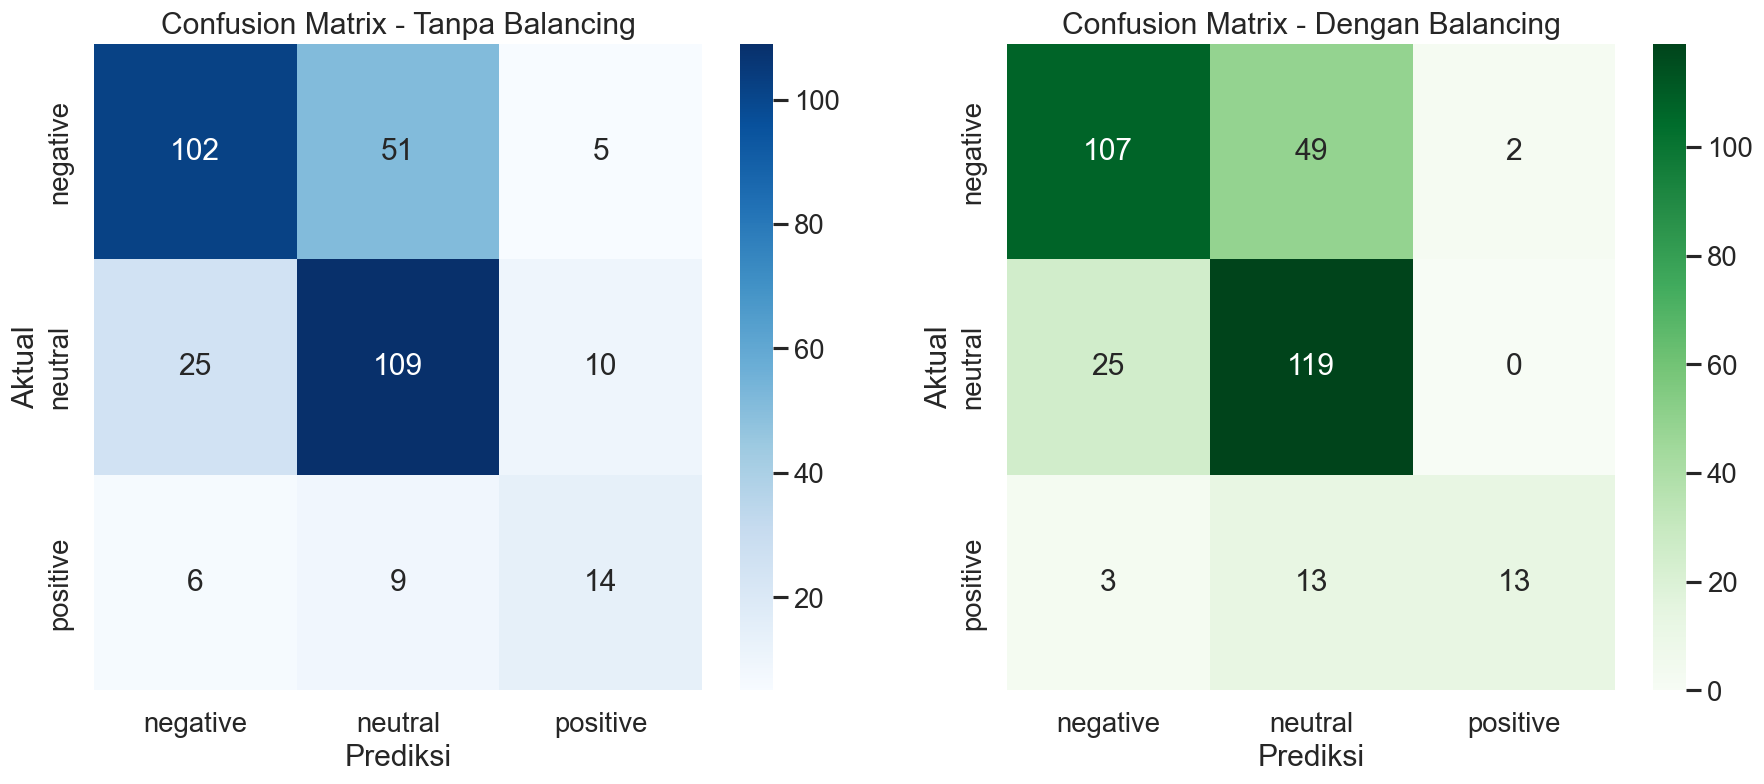

Gambar tersimpan pada: d:\sentimen-LTSM\figures\confusion_matrix_ablasi.png


In [98]:
# Cell 14.4 - Confusion matrix
# Pola kesalahan klasifikasi selanjutnya dianalisis melalui confusion matrix. Matriks ini membantu
# menunjukkan pasangan kelas yang paling sering tertukar, sehingga pengaruh balancing terhadap
# pengurangan kesalahan pada kelas yang kurang terwakili dapat dinilai secara lebih konkret.

cm_unbalanced = confusion_matrix(y_test_int, y_pred_unbalanced)
cm_balanced = confusion_matrix(y_test_int, y_pred_balanced)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
sns.heatmap(cm_unbalanced, annot=True, fmt='d', cmap='Blues', xticklabels=label_order, yticklabels=label_order, ax=axes[0])
axes[0].set_title('Confusion Matrix - Tanpa Balancing')
axes[0].set_xlabel('Prediksi')
axes[0].set_ylabel('Aktual')

sns.heatmap(cm_balanced, annot=True, fmt='d', cmap='Greens', xticklabels=label_order, yticklabels=label_order, ax=axes[1])
axes[1].set_title('Confusion Matrix - Dengan Balancing')
axes[1].set_xlabel('Prediksi')
axes[1].set_ylabel('Aktual')

cm_path = save_figure('confusion_matrix_ablasi.png')
plt.show()
print(f'Gambar tersimpan pada: {cm_path}')


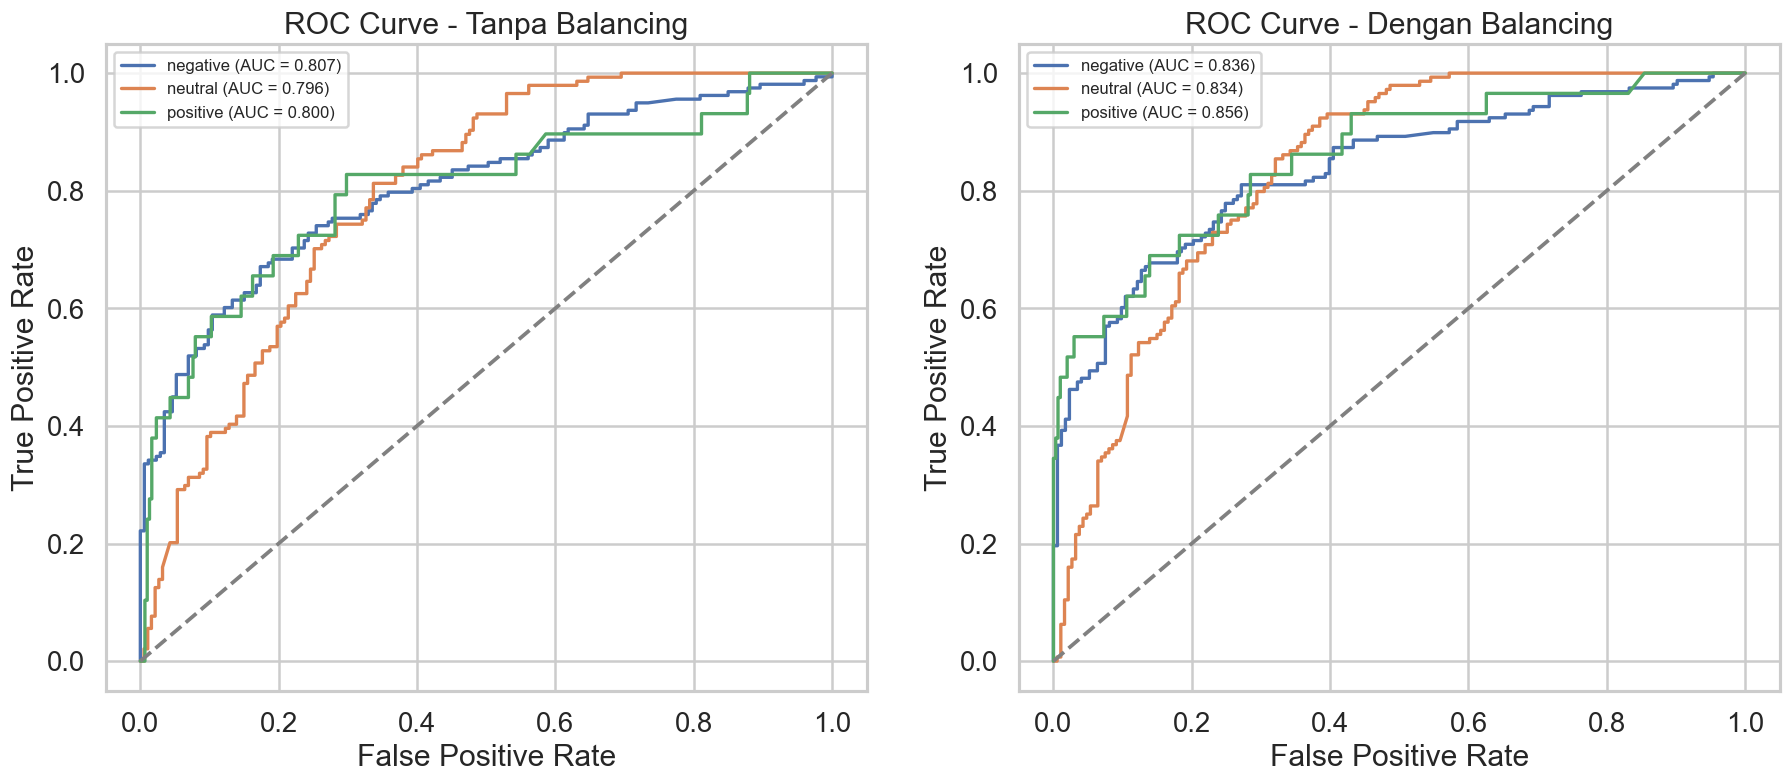

Gambar tersimpan pada: d:\sentimen-LTSM\figures\roc_curve_ablasi.png


In [99]:
# Cell 14.5 - ROC Curve dan AUC
# Kemampuan diskriminasi model kemudian diamati melalui kurva ROC one-vs-rest dan nilai AUC yang
# menyertainya. Penyajian ini melengkapi evaluasi sebelumnya dengan menekankan kemampuan model
# dalam membedakan setiap kelas sentimen pada berbagai ambang keputusan.

y_test_bin = label_binarize(y_test_int, classes=[0, 1, 2])

def plot_multiclass_roc(ax, y_true_bin, y_score, title):
    for idx, class_name in enumerate(label_order):
        fpr, tpr, _ = roc_curve(y_true_bin[:, idx], y_score[:, idx])
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, linewidth=2, label=f'{class_name} (AUC = {roc_auc:.3f})')
    ax.plot([0, 1], [0, 1], linestyle='--', color='gray')
    ax.set_title(title)
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.legend(fontsize=10)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
plot_multiclass_roc(axes[0], y_test_bin, y_prob_unbalanced, 'ROC Curve - Tanpa Balancing')
plot_multiclass_roc(axes[1], y_test_bin, y_prob_balanced, 'ROC Curve - Dengan Balancing')
roc_path = save_figure('roc_curve_ablasi.png')
plt.show()
print(f'Gambar tersimpan pada: {roc_path}')


Ringkasan perbandingan eksperimen:


,eksperimen,accuracy,f1_macro,auc_macro_ovr
0,tanpa_balancing,0.6798,0.6268,0.8010
1,dengan_balancing,0.7221,0.6845,0.8422


Eksperimen terbaik berdasarkan F1 makro: dengan_balancing


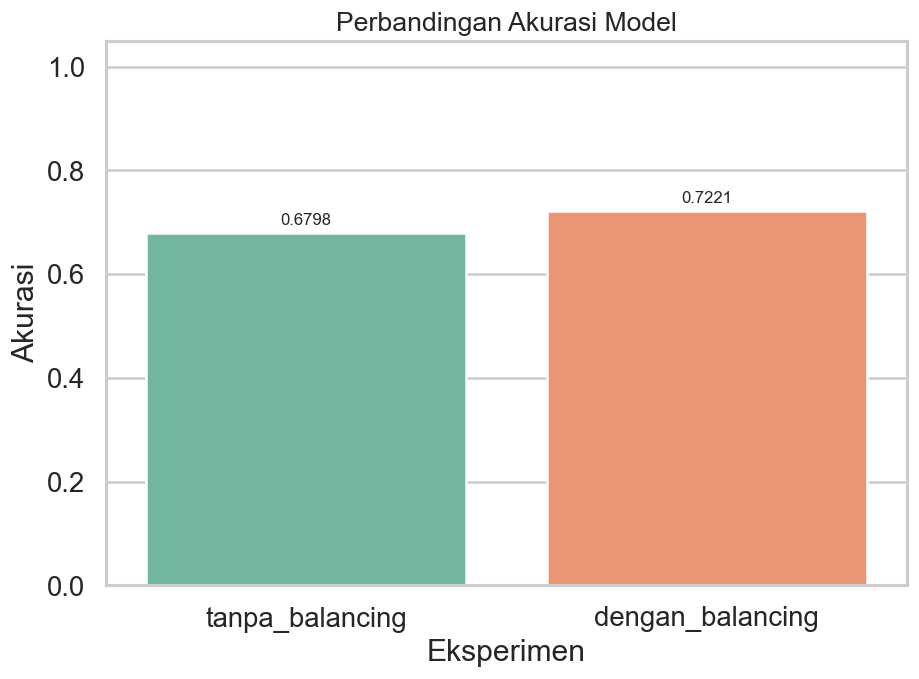

Gambar tersimpan pada: d:\sentimen-LTSM\figures\grafik_batang_perbandingan_akurasi.png


In [100]:
# Cell 14.6 - Ringkasan hasil ablasi
# Hasil kedua eksperimen kemudian diringkas secara komparatif agar pengaruh balancing terhadap mutu
# model dapat dibaca secara langsung. Perhatian utama diarahkan pada F1 makro sebagai indikator
# keseimbangan performa antar kelas, kemudian dilengkapi oleh akurasi dan AUC untuk memberikan
# konteks evaluatif yang lebih utuh.

best_row = metrics_df.sort_values(by='f1_macro', ascending=False).iloc[0]
print('Ringkasan perbandingan eksperimen:')
display(metrics_df[['eksperimen', 'accuracy', 'f1_macro', 'auc_macro_ovr']])
print(f"Eksperimen terbaik berdasarkan F1 makro: {best_row['eksperimen']}")

accuracy_comparison_df = metrics_df[['eksperimen', 'accuracy']].copy()
plt.figure(figsize=(8, 6))
ax = sns.barplot(data=accuracy_comparison_df, x='eksperimen', y='accuracy', palette='Set2')
ax.set_title('Perbandingan Akurasi Model', fontsize=16)
ax.set_xlabel('Eksperimen')
ax.set_ylabel('Akurasi')
ax.set_ylim(0, 1.05)
for container in ax.containers:
    ax.bar_label(container, fmt='%.4f', padding=3, fontsize=10)
plt.tight_layout()
accuracy_bar_path = save_figure('grafik_batang_perbandingan_akurasi.png')
plt.show()
print(f'Gambar tersimpan pada: {accuracy_bar_path}')


In [101]:
# Cell 15 - Simpan model dan artefak pelatihan
# Setelah model terbaik diidentifikasi, artefak pelatihan disimpan secara terstruktur agar hasil
# penelitian dapat digunakan kembali untuk inferensi, dokumentasi, maupun pengembangan lanjutan.
# Penyimpanan ini mencakup model, tokenizer, kamus label, Word2Vec, parameter, dan ringkasan
# evaluasi.

best_experiment = best_row['eksperimen']
best_model = model_balanced if best_experiment == 'dengan_balancing' else model_unbalanced
best_model_path = MODEL_DIR / f'model_terbaik_{best_experiment}.keras'
best_model.save(best_model_path)

with open(MODEL_DIR / 'tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)

with open(MODEL_DIR / 'label_mapping.json', 'w', encoding='utf-8') as f:
    json.dump({'label_to_int': label_to_int, 'int_to_label': int_to_label}, f, ensure_ascii=False, indent=2)

with open(MODEL_DIR / 'slang_dictionary_snapshot.json', 'w', encoding='utf-8') as f:
    json.dump(slang_dict, f, ensure_ascii=False, indent=2)

with open(MODEL_DIR / 'model_params.json', 'w', encoding='utf-8') as f:
    json.dump(MODEL_PARAMS, f, ensure_ascii=False, indent=2)

w2v_model.save(str(MODEL_DIR / 'word2vec.model'))
metrics_df.to_csv(MODEL_DIR / 'hasil_ablasi_metrics.csv', index=False)

print(f'Model terbaik tersimpan pada: {best_model_path}')
print(f'Seluruh artefak pelatihan tersimpan pada folder: {MODEL_DIR}')


Model terbaik tersimpan pada: d:\sentimen-LTSM\artifacts\model_terbaik_dengan_balancing.keras
Seluruh artefak pelatihan tersimpan pada folder: d:\sentimen-LTSM\artifacts


In [50]:
# Cell 16 - Uji coba model melalui antarmuka sederhana
# Sebagai penutup, hasil penelitian diimplementasikan dalam antarmuka sederhana untuk menguji
# prediksi pada komentar baru. Konsistensi dengan pipeline pelatihan dipertahankan agar proses
# inferensi merefleksikan prosedur yang sama dengan yang digunakan dalam pembentukan model.

def preprocess_for_inference(text):
    cleaned = clean_text(text)
    normalized = normalize_text(cleaned, slang_dict)
    tokens = tokenize_text(normalized)
    tokens = remove_stopwords(tokens, stopword_set, negation_words)
    tokens = stem_tokens(tokens)
    tokens = lemmatize_tokens(tokens)
    final_text = ' '.join(tokens).strip()
    return final_text

def predict_sentiment(text):
    processed_text = preprocess_for_inference(text)
    sequence = tokenizer.texts_to_sequences([processed_text])
    padded = pad_sequences(sequence, maxlen=MAX_SEQUENCE_LENGTH, padding='post', truncating='post')
    probabilities = best_model.predict(padded, verbose=0)[0]
    predicted_index = int(np.argmax(probabilities))
    predicted_label = int_to_label[predicted_index]
    probability_df = pd.DataFrame({
        'kelas': label_order,
        'probabilitas': probabilities
    }).sort_values(by='probabilitas', ascending=False)
    return processed_text, predicted_label, probability_df

comment_input = widgets.Textarea(
    value='Komentar ini sangat meresahkan karena videonya tampak meyakinkan tetapi belum tentu benar.',
    placeholder='Masukkan komentar TikTok di sini',
    description='Komentar:',
    layout=widgets.Layout(width='100%', height='150px')
)
predict_button = widgets.Button(description='Prediksi Sentimen', button_style='primary')
output_area = widgets.Output()

def on_predict_clicked(_):
    with output_area:
        clear_output()
        processed_text, predicted_label, probability_df = predict_sentiment(comment_input.value)
        display(Markdown(f'**Teks hasil pra-pemrosesan:** {processed_text if processed_text else "(kosong)"}'))
        display(Markdown(f'**Hasil prediksi kelas:** {predicted_label.title()}'))
        display(probability_df.style.format({'probabilitas': '{:.4f}'}))

predict_button.on_click(on_predict_clicked)
display(comment_input, predict_button, output_area)


Textarea(value='Komentar ini sangat meresahkan karena videonya tampak meyakinkan tetapi belum tentu benar.', d…

Button(button_style='primary', description='Prediksi Sentimen', style=ButtonStyle())

Output()